In [6]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path

In [7]:
from pathlib import Path
print(Path.cwd())

c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\notebooks


In [8]:
from pathlib import Path

BASE_DIR = Path.cwd().parent

firms_file = BASE_DIR / "data" / "firms" / "fire_nrt_SV-C2_809176.shp"

print("FIRMS file:", firms_file)

gdf = gpd.read_file(firms_file)

print("Total records:", len(gdf))
print("Total columns:", len(gdf.columns))

FIRMS file: c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\data\firms\fire_nrt_SV-C2_809176.shp
Total records: 7615
Total columns: 15


In [9]:
gdf.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,geometry
0,23.64860,85.44053,339.62,0.41,0.45,2026-07-01,0714,SNPP,SNPP,n,2.0NRT,291.98,7.47,D,POINT (85.44053 23.6486)
1,25.39800,84.50601,331.43,0.43,0.46,2026-07-01,0714,SNPP,SNPP,n,2.0NRT,294.12,1.49,D,POINT (84.50601 25.398)
2,8.74252,78.16695,347.39,0.34,0.56,2026-07-01,0850,SNPP,SNPP,n,2.0NRT,289.56,3.78,D,POINT (78.16695 8.74252)
3,8.74769,78.16627,330.81,0.34,0.56,2026-07-01,0850,SNPP,SNPP,n,2.0NRT,294.08,3.78,D,POINT (78.16627 8.74769)
4,8.89629,77.95658,340.74,0.33,0.55,2026-07-01,0850,SNPP,SNPP,n,2.0NRT,296.34,2.21,D,POINT (77.95658 8.89629)


In [10]:
gdf.columns.tolist()

['LATITUDE',
 'LONGITUDE',
 'BRIGHTNESS',
 'SCAN',
 'TRACK',
 'ACQ_DATE',
 'ACQ_TIME',
 'SATELLITE',
 'INSTRUMENT',
 'CONFIDENCE',
 'VERSION',
 'BRIGHT_T31',
 'FRP',
 'DAYNIGHT',
 'geometry']

In [11]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [12]:
gdf.isnull().sum()

LATITUDE      0
LONGITUDE     0
BRIGHTNESS    0
SCAN          0
TRACK         0
ACQ_DATE      0
ACQ_TIME      0
SATELLITE     0
INSTRUMENT    0
CONFIDENCE    0
VERSION       0
BRIGHT_T31    0
FRP           0
DAYNIGHT      0
geometry      0
dtype: int64

In [13]:
gdf.describe()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,BRIGHT_T31,FRP
count,7615.000000,7615.000000,7615.000000,7615.000000,7615.000000,7615,7615.000000,7615.000000
mean,19.649239,81.240875,318.005078,0.446675,0.462629,2026-08-22 13:21:47.156000,289.588273,3.038032
min,8.171750,68.552560,295.010000,0.320000,0.360000,2026-07-01 00:00:00,243.100000,0.140000
25%,15.173720,77.501690,305.430000,0.390000,0.370000,2026-08-06 00:00:00,285.240000,1.210000
50%,21.377430,81.590840,311.310000,0.420000,0.420000,2026-08-30 00:00:00,290.000000,2.030000
75%,23.692895,85.853880,332.890000,0.490000,0.540000,2026-09-11 00:00:00,294.370000,3.630000
max,34.454430,97.029450,367.000000,0.790000,0.780000,2026-09-19 00:00:00,318.060000,94.070000
std,5.771999,5.183210,15.501625,0.078785,0.107198,NaN,8.465861,3.514531


In [14]:
gdf[[
    "BRIGHTNESS",
    "SCAN",
    "TRACK",
    "CONFIDENCE",
    "BRIGHT_T31",
    "FRP"
]].describe()

,BRIGHTNESS,SCAN,TRACK,BRIGHT_T31,FRP
count,7615.000000,7615.000000,7615.000000,7615.000000,7615.000000
mean,318.005078,0.446675,0.462629,289.588273,3.038032
std,15.501625,0.078785,0.107198,8.465861,3.514531
min,295.010000,0.320000,0.360000,243.100000,0.140000
25%,305.430000,0.390000,0.370000,285.240000,1.210000
50%,311.310000,0.420000,0.420000,290.000000,2.030000
75%,332.890000,0.490000,0.540000,294.370000,3.630000
max,367.000000,0.790000,0.780000,318.060000,94.070000


In [15]:
gdf["CONFIDENCE"].value_counts()

CONFIDENCE
n    7362
l     221
h      32
Name: count, dtype: int64

In [16]:
gdf["DAYNIGHT"].value_counts()

DAYNIGHT
N    5215
D    2400
Name: count, dtype: int64

In [17]:
gdf[["BRIGHTNESS", "FRP"]].corr()

,BRIGHTNESS,FRP
BRIGHTNESS,1.000000,0.590944
FRP,0.590944,1.000000


In [18]:
gdf["ACQ_DATE"].min(), gdf["ACQ_DATE"].max()

(Timestamp('2026-07-01 00:00:00'), Timestamp('2026-09-19 00:00:00'))

In [19]:
daily_counts = (
    gdf.groupby("ACQ_DATE")
       .size()
       .reset_index(name="detections")
)

daily_counts.head(10)

,ACQ_DATE,detections
0,2026-07-01,45
1,2026-07-02,52
2,2026-07-03,56
3,2026-07-04,75
4,2026-07-05,40
5,2026-07-06,55
6,2026-07-07,54
7,2026-07-08,70
8,2026-07-09,74
9,2026-07-10,27


In [20]:
gdf["LAT_GRID"] = gdf["LATITUDE"].round(2)
gdf["LON_GRID"] = gdf["LONGITUDE"].round(2)

gdf[["LATITUDE", "LONGITUDE", "LAT_GRID", "LON_GRID"]].head(10)

,LATITUDE,LONGITUDE,LAT_GRID,LON_GRID
0,23.64860,85.44053,23.65,85.44
1,25.39800,84.50601,25.40,84.51
2,8.74252,78.16695,8.74,78.17
3,8.74769,78.16627,8.75,78.17
4,8.89629,77.95658,8.90,77.96
5,8.74728,78.16316,8.75,78.16
6,9.55491,78.18633,9.55,78.19
7,10.46489,79.32489,10.46,79.32
8,22.13597,69.07013,22.14,69.07
9,23.73032,68.61646,23.73,68.62


In [21]:
# Count unique observation dates for each approximate location
persistence = (
    gdf.groupby(["LAT_GRID", "LON_GRID"])["ACQ_DATE"]
       .nunique()
       .reset_index(name="unique_days")
)

# Show locations detected on multiple days first
persistence.sort_values("unique_days", ascending=False).head(20)

,LAT_GRID,LON_GRID,unique_days
2202,23.76,86.40,26
1779,21.11,72.65,26
1988,22.37,87.30,24
1775,21.10,72.64,24
1992,22.38,87.28,24
1352,15.18,76.66,23
2239,23.80,86.33,23
1353,15.18,76.67,23
2148,23.68,86.40,22
2190,23.74,86.43,21


In [22]:
# Merge the number of unique detection days
# back into the original FIRMS dataset
gdf = gdf.merge(
    persistence,
    on=["LAT_GRID", "LON_GRID"],
    how="left"
)

# Check the result
gdf[
    [
        "LATITUDE",
        "LONGITUDE",
        "ACQ_DATE",
        "LAT_GRID",
        "LON_GRID",
        "unique_days"
    ]
].head(10)

,LATITUDE,LONGITUDE,ACQ_DATE,LAT_GRID,LON_GRID,unique_days
0,23.64860,85.44053,2026-07-01,23.65,85.44,16
1,25.39800,84.50601,2026-07-01,25.40,84.51,1
2,8.74252,78.16695,2026-07-01,8.74,78.17,1
3,8.74769,78.16627,2026-07-01,8.75,78.17,1
4,8.89629,77.95658,2026-07-01,8.90,77.96,1
5,8.74728,78.16316,2026-07-01,8.75,78.16,2
6,9.55491,78.18633,2026-07-01,9.55,78.19,1
7,10.46489,79.32489,2026-07-01,10.46,79.32,1
8,22.13597,69.07013,2026-07-01,22.14,69.07,1
9,23.73032,68.61646,2026-07-01,23.73,68.62,1


In [23]:
# Create a persistence label
# 1 = detected on 3 or more different days
# 0 = detected on fewer than 3 different days

gdf["persistent"] = (
    gdf["unique_days"] >= 3
).astype(int)

# Count persistent vs non-persistent detections
gdf["persistent"].value_counts()

persistent
1    4726
0    2889
Name: count, dtype: int64

In [24]:
# Calculate the thermal anomaly difference
# Higher values indicate a larger difference between
# fire brightness temperature and background temperature

gdf["TEMP_DIFF"] = (
    gdf["BRIGHTNESS"] - gdf["BRIGHT_T31"]
)

# Check the newly created feature
gdf[
    ["BRIGHTNESS", "BRIGHT_T31", "TEMP_DIFF"]
].head(10)

,BRIGHTNESS,BRIGHT_T31,TEMP_DIFF
0,339.62,291.98,47.64
1,331.43,294.12,37.31
2,347.39,289.56,57.83
3,330.81,294.08,36.73
4,340.74,296.34,44.40
5,333.22,293.83,39.39
6,353.07,293.54,59.53
7,336.60,287.41,49.19
8,335.39,301.71,33.68
9,345.18,303.48,41.70


In [25]:
# Create a log-transformed FRP feature
# Log transformation reduces the effect of very large FRP values
# and makes the feature more suitable for machine learning.

gdf["FRP_LOG"] = np.log1p(gdf["FRP"])

# Check the original and transformed FRP values
gdf[["FRP", "FRP_LOG"]].head(10)

,FRP,FRP_LOG
0,7.47,2.136531
1,1.49,0.912283
2,3.78,1.564441
3,3.78,1.564441
4,2.21,1.166271
5,5.31,1.842136
6,2.95,1.373716
7,4.18,1.644805
8,2.47,1.244155
9,3.80,1.568616


In [26]:
# Convert DAYNIGHT into a numerical feature
# 1 = Night detection
# 0 = Day detection

gdf["IS_NIGHT"] = (
    gdf["DAYNIGHT"] == "N"
).astype(int)

# Check the conversion
gdf[["DAYNIGHT", "IS_NIGHT"]].head(10)

,DAYNIGHT,IS_NIGHT
0,D,0
1,D,0
2,D,0
3,D,0
4,D,0
5,D,0
6,D,0
7,D,0
8,D,0
9,D,0


In [27]:
# Convert FIRMS confidence levels into numerical values
# n = nominal, l = low, h = high
# Higher value means higher reported confidence

confidence_map = {
    "l": 0,
    "n": 1,
    "h": 2
}

gdf["CONFIDENCE_NUM"] = (
    gdf["CONFIDENCE"]
    .map(confidence_map)
)

# Check the conversion
gdf[["CONFIDENCE", "CONFIDENCE_NUM"]].head(10)

,CONFIDENCE,CONFIDENCE_NUM
0,n,1
1,n,1
2,n,1
3,n,1
4,n,1
5,n,1
6,n,1
7,n,1
8,n,1
9,n,1


In [28]:
# Convert FIRMS confidence levels into numerical values
# l = low, n = nominal, h = high

confidence_map = {
    "l": 0,
    "n": 1,
    "h": 2
}

gdf["CONFIDENCE_NUM"] = gdf["CONFIDENCE"].map(confidence_map)

In [29]:
# Display the important features created so far

feature_columns = [
    "BRIGHTNESS",
    "BRIGHT_T31",
    "FRP",
    "TEMP_DIFF",
    "FRP_LOG",
    "IS_NIGHT",
    "CONFIDENCE_NUM",
    "unique_days",
    "persistent"
]

gdf[feature_columns].describe()

,BRIGHTNESS,BRIGHT_T31,FRP,TEMP_DIFF,FRP_LOG,IS_NIGHT,CONFIDENCE_NUM,unique_days,persistent
count,7615.000000,7615.000000,7615.000000,7615.000000,7615.000000,7615.000000,7615.000000,7615.000000,7615.000000
mean,318.005078,289.588273,3.038032,28.416805,1.208428,0.684833,0.975181,7.884439,0.620617
std,15.501625,8.465861,3.514531,11.505353,0.558103,0.464613,0.180588,7.046492,0.485265
min,295.010000,243.100000,0.140000,10.030000,0.131028,0.000000,0.000000,1.000000,0.000000
25%,305.430000,285.240000,1.210000,18.770000,0.792993,0.000000,1.000000,1.000000,0.000000
50%,311.310000,290.000000,2.030000,26.140000,1.108563,1.000000,1.000000,6.000000,1.000000
75%,332.890000,294.370000,3.630000,36.560000,1.532557,1.000000,1.000000,13.000000,1.000000
max,367.000000,318.060000,94.070000,88.140000,4.554613,1.000000,2.000000,26.000000,1.000000


In [30]:
# Check the first few rows of our engineered features
# These will later be used for the machine learning pipeline

gdf[
    [
        "LATITUDE",
        "LONGITUDE",
        "BRIGHTNESS",
        "BRIGHT_T31",
        "FRP",
        "TEMP_DIFF",
        "FRP_LOG",
        "IS_NIGHT",
        "CONFIDENCE_NUM",
        "unique_days",
        "persistent"
    ]
].head(10)

,LATITUDE,LONGITUDE,BRIGHTNESS,BRIGHT_T31,FRP,TEMP_DIFF,FRP_LOG,IS_NIGHT,CONFIDENCE_NUM,unique_days,persistent
0,23.64860,85.44053,339.62,291.98,7.47,47.64,2.136531,0,1,16,1
1,25.39800,84.50601,331.43,294.12,1.49,37.31,0.912283,0,1,1,0
2,8.74252,78.16695,347.39,289.56,3.78,57.83,1.564441,0,1,1,0
3,8.74769,78.16627,330.81,294.08,3.78,36.73,1.564441,0,1,1,0
4,8.89629,77.95658,340.74,296.34,2.21,44.40,1.166271,0,1,1,0
5,8.74728,78.16316,333.22,293.83,5.31,39.39,1.842136,0,1,2,0
6,9.55491,78.18633,353.07,293.54,2.95,59.53,1.373716,0,1,1,0
7,10.46489,79.32489,336.60,287.41,4.18,49.19,1.644805,0,1,1,0
8,22.13597,69.07013,335.39,301.71,2.47,33.68,1.244155,0,1,1,0
9,23.73032,68.61646,345.18,303.48,3.80,41.70,1.568616,0,1,1,0


In [31]:
# Check how many detections are persistent and non-persistent
# This helps us understand whether the target classes are balanced

class_counts = gdf["persistent"].value_counts()

print("Persistent class distribution:")
print(class_counts)

# Show percentage of each class
print("\nClass percentage:")
print(
    (gdf["persistent"].value_counts(normalize=True) * 100).round(2)
)

Persistent class distribution:
persistent
1    4726
0    2889
Name: count, dtype: int64

Class percentage:
persistent
1    62.06
0    37.94
Name: proportion, dtype: float64


In [32]:
# Select the numerical features that may be useful for ML
# 'persistent' is the target, so it is kept separately

ml_features = [
    "BRIGHTNESS",
    "BRIGHT_T31",
    "FRP",
    "TEMP_DIFF",
    "FRP_LOG",
    "IS_NIGHT",
    "CONFIDENCE_NUM"
]

# Calculate correlation between the selected features
# and the persistence target
correlation_with_target = (
    gdf[ml_features + ["persistent"]]
    .corr()["persistent"]
    .sort_values(ascending=False)
)

print("Correlation with persistence:")
print(correlation_with_target)

Correlation with persistence:
persistent        1.000000
IS_NIGHT          0.571740
CONFIDENCE_NUM    0.112848
FRP              -0.248878
FRP_LOG          -0.285406
TEMP_DIFF        -0.341946
BRIGHT_T31       -0.415062
BRIGHTNESS       -0.480470
Name: persistent, dtype: float64


In [33]:
# Create a separate dataframe for machine learning
# We intentionally DO NOT include 'unique_days'
# because persistent is directly created from unique_days.
# Including it would cause target leakage.

X = gdf[ml_features].copy()

# Define the target variable
y = gdf["persistent"].copy()

# Check the resulting shapes
print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

# Display the first few rows
X.head()

Feature data shape: (7615, 7)
Target data shape: (7615,)


,BRIGHTNESS,BRIGHT_T31,FRP,TEMP_DIFF,FRP_LOG,IS_NIGHT,CONFIDENCE_NUM
0,339.62,291.98,7.47,47.64,2.136531,0,1
1,331.43,294.12,1.49,37.31,0.912283,0,1
2,347.39,289.56,3.78,57.83,1.564441,0,1
3,330.81,294.08,3.78,36.73,1.564441,0,1
4,340.74,296.34,2.21,44.40,1.166271,0,1


In [34]:
# Check which Python interpreter is being used by the Jupyter notebook
import sys

print("Jupyter Python:")
print(sys.executable)

Jupyter Python:
c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\venv\Scripts\python.exe


In [35]:
# Check whether scikit-learn is available in the selected environment
import sklearn

# Display the installed scikit-learn version
print("Scikit-learn version:", sklearn.__version__)

Scikit-learn version: 1.9.1


In [36]:
# Define the numerical features that will be used by the ML model
# 'unique_days' is intentionally excluded because it directly creates
# our 'persistent' target and would cause target leakage

ml_features = [
    "BRIGHTNESS",
    "BRIGHT_T31",
    "FRP",
    "TEMP_DIFF",
    "FRP_LOG",
    "IS_NIGHT",
    "CONFIDENCE_NUM"
]

# Create the input feature dataset
X = gdf[ml_features].copy()

# Create the target variable
# 1 = persistent detection
# 0 = non-persistent detection
y = gdf["persistent"].copy()

# Display the shapes to verify the data
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7615, 7)
y shape: (7615,)


In [37]:
# Import the function used to split data into training and testing sets
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training and 20% testing data
# stratify=y keeps the same class ratio in both datasets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the sizes of the resulting datasets
print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (6092, 7)
Testing data : (1523, 7)


In [38]:
# Import the Random Forest model and evaluation metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Create the Random Forest classifier
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train the model only on the training dataset
model.fit(X_train, y_train)

# Predict the classes for the unseen test dataset
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Display the results
print("===== MODEL EVALUATION =====")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

# Display detailed class-wise performance
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred, zero_division=0))

===== MODEL EVALUATION =====
Accuracy : 0.7853
Precision: 0.8259
Recall   : 0.8286
F1 Score : 0.8273

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.72      0.71      0.72       578
           1       0.83      0.83      0.83       945

    accuracy                           0.79      1523
   macro avg       0.77      0.77      0.77      1523
weighted avg       0.79      0.79      0.79      1523



In [39]:
# Import the Random Forest model and evaluation metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Create the Random Forest classifier
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train the model only on the training dataset
model.fit(X_train, y_train)

# Predict the classes for the unseen test dataset
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Display the results
print("===== MODEL EVALUATION =====")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

# Display detailed class-wise performance
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred, zero_division=0))

===== MODEL EVALUATION =====
Accuracy : 0.7853
Precision: 0.8259
Recall   : 0.8286
F1 Score : 0.8273

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.72      0.71      0.72       578
           1       0.83      0.83      0.83       945

    accuracy                           0.79      1523
   macro avg       0.77      0.77      0.77      1523
weighted avg       0.79      0.79      0.79      1523



In [40]:
# Import the confusion matrix function
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix from actual and predicted labels
cm = confusion_matrix(y_test, y_pred)

# Display the matrix
print("===== CONFUSION MATRIX =====")
print(cm)

# Explain the matrix layout
print("\nRows = Actual class")
print("Columns = Predicted class")
print("Class 0 = Non-persistent")
print("Class 1 = Persistent")

===== CONFUSION MATRIX =====
[[413 165]
 [162 783]]

Rows = Actual class
Columns = Predicted class
Class 0 = Non-persistent
Class 1 = Persistent


In [41]:
# Get the importance of every feature from the trained Random Forest
feature_importance = (
    model.feature_importances_
)

# Combine feature names with their importance values
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
})

# Sort features from most important to least important
importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

# Display the feature importance
print("===== FEATURE IMPORTANCE =====")
print(importance_df)

===== FEATURE IMPORTANCE =====
          Feature  Importance
0      BRIGHTNESS    0.242358
1      BRIGHT_T31    0.194608
3       TEMP_DIFF    0.166975
5        IS_NIGHT    0.136570
2             FRP    0.128655
4         FRP_LOG    0.127198
6  CONFIDENCE_NUM    0.003637


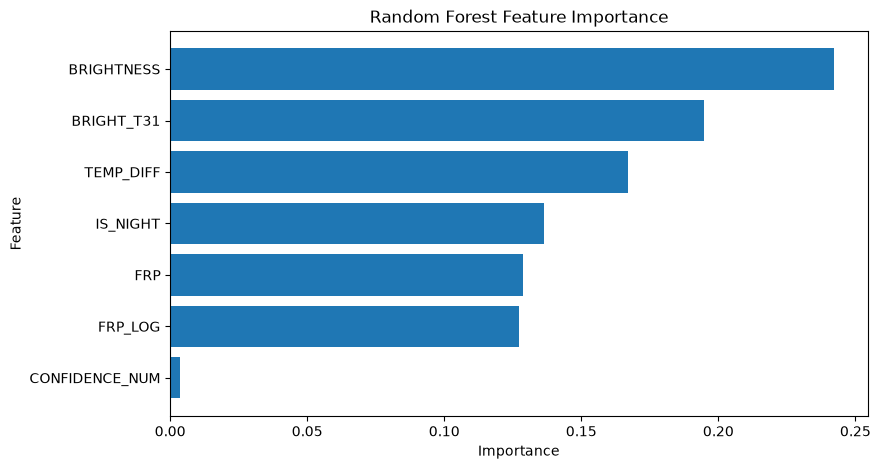

In [43]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Create a bar chart of feature importance
plt.figure(figsize=(9, 5))

# Plot features from highest to lowest importance
plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

# Put the most important feature at the top
plt.gca().invert_yaxis()

# Add chart title and labels
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

# Display the chart
plt.show()

In [44]:
# Check the geographic boundary covered by the NASA FIRMS detections
# This tells us the latitude and longitude range of our dataset

print("Minimum Latitude :", gdf["LATITUDE"].min())
print("Maximum Latitude :", gdf["LATITUDE"].max())

print("Minimum Longitude:", gdf["LONGITUDE"].min())
print("Maximum Longitude:", gdf["LONGITUDE"].max())

Minimum Latitude : 8.17175
Maximum Latitude : 34.45443
Minimum Longitude: 68.55256
Maximum Longitude: 97.02945


In [45]:
# Count the approximate spatial locations created earlier
# LAT_GRID and LON_GRID represent rounded FIRMS coordinates

unique_locations = (
    gdf[["LAT_GRID", "LON_GRID"]]
    .drop_duplicates()
)

# Display the number of unique approximate locations
print("Unique FIRMS locations:", len(unique_locations))

# Display a few example locations
print("\nSample locations:")
print(unique_locations.head(10))

Unique FIRMS locations: 2699

Sample locations:
   LAT_GRID  LON_GRID
0     23.65     85.44
1     25.40     84.51
2      8.74     78.17
3      8.75     78.17
4      8.90     77.96
5      8.75     78.16
6      9.55     78.19
7     10.46     79.32
8     22.14     69.07
9     23.73     68.62


In [46]:
# Create a path for the future industrial-site dataset
# This file will later contain industrial facility coordinates

from pathlib import Path

# Get the project root directory
BASE_DIR = Path.cwd().parent

# Define the industrial-site CSV location
industrial_file = BASE_DIR / "data" / "industrial_sites.csv"

# Display where the file should be placed
print("Industrial sites file should be:")
print(industrial_file)

Industrial sites file should be:
c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\data\industrial_sites.csv


In [47]:
# Import pandas for creating the industrial-site table
import pandas as pd

# Create a starter industrial-site dataset
# These are example locations only, so they are clearly marked as sample data.
# Later we should replace these with verified OSM/official industrial locations.
industrial_sites = pd.DataFrame({
    "site_name": [
        "Sample Industrial Site 1",
        "Sample Industrial Site 2",
        "Sample Industrial Site 3"
    ],
    "latitude": [
        23.76,
        21.11,
        22.37
    ],
    "longitude": [
        86.40,
        72.65,
        87.30
    ]
})

# Save the sample industrial locations
industrial_file = BASE_DIR / "data" / "industrial_sites.csv"
industrial_sites.to_csv(industrial_file, index=False)

# Display the created data
print("Industrial sites saved at:")
print(industrial_file)

print("\nIndustrial sites:")
print(industrial_sites)

Industrial sites saved at:
c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\data\industrial_sites.csv

Industrial sites:
                  site_name  latitude  longitude
0  Sample Industrial Site 1     23.76      86.40
1  Sample Industrial Site 2     21.11      72.65
2  Sample Industrial Site 3     22.37      87.30


In [48]:
# Read the industrial-site CSV back into pandas
# This verifies that the file was created correctly.

industrial_df = pd.read_csv(industrial_file)

# Display the stored industrial locations
print(industrial_df)

                  site_name  latitude  longitude
0  Sample Industrial Site 1     23.76      86.40
1  Sample Industrial Site 2     21.11      72.65
2  Sample Industrial Site 3     22.37      87.30


In [50]:
# Import folium for creating an interactive geographic map
import folium

# Calculate the center of the FIRMS dataset
map_center = [
    gdf["LATITUDE"].mean(),
    gdf["LONGITUDE"].mean()
]

# Create the interactive map
fire_map = folium.Map(
    location=map_center,
    zoom_start=5
)

# Add industrial sites to the map
for _, row in industrial_df.iterrows():

    # Add a marker for each industrial location
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        popup=row["site_name"],
        icon=folium.Icon(icon="industry")
    ).add_to(fire_map)

# Display the map
fire_map

In [51]:
# Import required libraries
import os
from dotenv import load_dotenv

# Load the .env file from the project root
load_dotenv(BASE_DIR / ".env")

# Read the NASA FIRMS MAP_KEY
firms_map_key = os.getenv("NASA_FIRMS_MAP_KEY")

# Check only whether the key was loaded
# We do not print the actual key for security
if firms_map_key:
    print("✅ NASA FIRMS MAP_KEY loaded successfully.")
else:
    print("❌ MAP_KEY not found. Check your .env file.")

✅ NASA FIRMS MAP_KEY loaded successfully.


In [53]:
# Import requests for connecting to NASA FIRMS
import requests

# Define India's approximate bounding box
# Format: west, south, east, north
india_bbox = "68,6,97,37"

# Build the NASA FIRMS API URL using the bounding box
firms_url = (
    f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/"
    f"{firms_map_key}/VIIRS_SNPP_NRT/{india_bbox}/1"
)

# Send the request to NASA FIRMS
response = requests.get(
    firms_url,
    timeout=60
)

# Display the response status
print("HTTP Status:", response.status_code)

# Check whether the request was successful
if response.status_code == 200:
    print("✅ NASA FIRMS API connection successful!")
else:
    print("❌ FIRMS API request failed.")
    print(response.text[:500])

HTTP Status: 200
✅ NASA FIRMS API connection successful!


In [54]:
# Import StringIO to read the API response as CSV text
from io import StringIO

# Convert the successful FIRMS response into a pandas DataFrame
if response.status_code == 200:

    # Read the CSV data returned by NASA FIRMS
    firms_api_df = pd.read_csv(
        StringIO(response.text)
    )

    # Display basic information
    print("Real FIRMS records:", len(firms_api_df))

    # Display the available columns
    print("\nColumns:")
    print(firms_api_df.columns.tolist())

    # Show the first five records
    display(firms_api_df.head())

Real FIRMS records: 106

Columns:
['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight']


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,25.53974,96.71659,330.07,0.48,0.40,2026-09-21,637,N,VIIRS,n,2.0NRT,296.97,2.43,D
1,36.31959,94.79975,333.54,0.42,0.38,2026-09-21,642,N,VIIRS,l,2.0NRT,308.02,2.02,D
2,36.32042,94.80437,340.17,0.42,0.38,2026-09-21,642,N,VIIRS,n,2.0NRT,308.87,2.02,D
3,36.32299,94.79882,346.10,0.42,0.38,2026-09-21,642,N,VIIRS,n,2.0NRT,308.36,2.02,D
4,36.32382,94.80344,344.58,0.42,0.38,2026-09-21,642,N,VIIRS,n,2.0NRT,307.78,2.02,D


In [55]:
# Define the output path for the latest real NASA FIRMS data
api_output_file = BASE_DIR / "outputs" / "firms_api_latest.csv"

# Save the API data as a CSV file
firms_api_df.to_csv(
    api_output_file,
    index=False
)

# Confirm where the file was saved
print("Real FIRMS data saved successfully:")
print(api_output_file)

# Show the number of records saved
print("Total records:", len(firms_api_df))


Real FIRMS data saved successfully:
c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\outputs\firms_api_latest.csv
Total records: 106


In [56]:
# Select important columns for our fire-detection analysis
important_columns = [
    "latitude",
    "longitude",
    "bright_ti4",
    "scan",
    "track",
    "acq_date",
    "acq_time",
    "satellite",
    "confidence",
    "frp"
]

# Display only columns that are actually present in the API response
available_columns = [
    column for column in important_columns
    if column in firms_api_df.columns
]

# Show the available important fields
print("Available FIRMS fields:")
print(available_columns)

# Display the first five records
display(firms_api_df[available_columns].head())

Available FIRMS fields:
['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'confidence', 'frp']


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,confidence,frp
0,25.53974,96.71659,330.07,0.48,0.40,2026-09-21,637,N,n,2.43
1,36.31959,94.79975,333.54,0.42,0.38,2026-09-21,642,N,l,2.02
2,36.32042,94.80437,340.17,0.42,0.38,2026-09-21,642,N,n,2.02
3,36.32299,94.79882,346.10,0.42,0.38,2026-09-21,642,N,n,2.02
4,36.32382,94.80344,344.58,0.42,0.38,2026-09-21,642,N,n,2.02


In [57]:
# Check the size and date range of the real FIRMS API dataset

print("Total FIRMS API records:", len(firms_api_df))

# Check the available acquisition dates
if "acq_date" in firms_api_df.columns:
    print(
        "Date range:",
        firms_api_df["acq_date"].min(),
        "to",
        firms_api_df["acq_date"].max()
    )

# Check confidence distribution if available
if "confidence" in firms_api_df.columns:
    print("\nConfidence distribution:")
    print(firms_api_df["confidence"].value_counts())

Total FIRMS API records: 106
Date range: 2026-09-21 to 2026-09-21

Confidence distribution:
confidence
n    86
l    20
Name: count, dtype: int64


In [58]:
# Import GeoPandas for GIS operations
import geopandas as gpd

# Import pandas for tabular data handling
import pandas as pd

# Define the path where OSM industrial locations will be stored
osm_file = BASE_DIR / "data" / "industrial_sites.csv"

# Check whether the OSM/industrial CSV already exists
if osm_file.exists():
    # Load the existing industrial-site data
    industrial_df = pd.read_csv(osm_file)

    # Show the number of industrial locations
    print("Industrial sites loaded:", len(industrial_df))

    # Display the first few locations
    display(industrial_df.head())
else:
    # Inform the user if the file has not been created yet
    print("industrial_sites.csv not found.")
    print("Next step: create/download the OSM industrial locations.")

Industrial sites loaded: 3


,site_name,latitude,longitude
0,Sample Industrial Site 1,23.76,86.40
1,Sample Industrial Site 2,21.11,72.65
2,Sample Industrial Site 3,22.37,87.30


In [59]:
# Create a GeoDataFrame from the real FIRMS API data
# longitude is the X coordinate and latitude is the Y coordinate
firms_gdf = gpd.GeoDataFrame(
    firms_api_df.copy(),
    geometry=gpd.points_from_xy(
        firms_api_df["longitude"],
        firms_api_df["latitude"]
    ),
    crs="EPSG:4326"
)

# Display the coordinate system
print("FIRMS CRS:", firms_gdf.crs)

# Display the first few FIRMS points
display(firms_gdf.head())

FIRMS CRS: EPSG:4326


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,geometry
0,25.53974,96.71659,330.07,0.48,0.40,2026-09-21,637,N,VIIRS,n,2.0NRT,296.97,2.43,D,POINT (96.71659 25.53974)
1,36.31959,94.79975,333.54,0.42,0.38,2026-09-21,642,N,VIIRS,l,2.0NRT,308.02,2.02,D,POINT (94.79975 36.31959)
2,36.32042,94.80437,340.17,0.42,0.38,2026-09-21,642,N,VIIRS,n,2.0NRT,308.87,2.02,D,POINT (94.80437 36.32042)
3,36.32299,94.79882,346.10,0.42,0.38,2026-09-21,642,N,VIIRS,n,2.0NRT,308.36,2.02,D,POINT (94.79882 36.32299)
4,36.32382,94.80344,344.58,0.42,0.38,2026-09-21,642,N,VIIRS,n,2.0NRT,307.78,2.02,D,POINT (94.80344 36.32382)


In [60]:
# Check the geographical extent of the real FIRMS API data

print("Minimum longitude:", firms_gdf.geometry.x.min())
print("Maximum longitude:", firms_gdf.geometry.x.max())

print("Minimum latitude:", firms_gdf.geometry.y.min())
print("Maximum latitude:", firms_gdf.geometry.y.max())

# Confirm that the FIRMS points are valid
print("\nTotal FIRMS points:", len(firms_gdf))

Minimum longitude: 68.04147
Maximum longitude: 96.71659
Minimum latitude: 7.12867
Maximum latitude: 36.38238

Total FIRMS points: 106


In [67]:
# Get the geographical extent of our real NASA FIRMS data
# We will use this instead of querying the whole country.

min_lat = firms_gdf["latitude"].min()
max_lat = firms_gdf["latitude"].max()
min_lon = firms_gdf["longitude"].min()
max_lon = firms_gdf["longitude"].max()

# Add a small buffer around the FIRMS area
buffer = 0.25

north = max_lat + buffer
south = min_lat - buffer
east = max_lon + buffer
west = min_lon - buffer

# Display the area that will be queried
print("OSM query area:")
print("North:", north)
print("South:", south)
print("East :", east)
print("West :", west)

OSM query area:
North: 36.63238
South: 6.87867
East : 96.96659
West : 67.79147


In [69]:
# Check that our real NASA FIRMS data is still available
# We do not need OSM for this cell.

print("Real FIRMS records:", len(firms_gdf))

# Display the FIRMS coordinate range
print("\nLatitude range:")
print(firms_gdf["latitude"].min(), "to", firms_gdf["latitude"].max())

print("\nLongitude range:")
print(firms_gdf["longitude"].min(), "to", firms_gdf["longitude"].max())

# Display a few FIRMS detections
display(
    firms_gdf[
        ["latitude", "longitude", "acq_date", "frp", "confidence"]
    ].head()
)

Real FIRMS records: 106

Latitude range:
7.12867 to 36.38238

Longitude range:
68.04147 to 96.71659


,latitude,longitude,acq_date,frp,confidence
0,25.53974,96.71659,2026-09-21,2.43,n
1,36.31959,94.79975,2026-09-21,2.02,l
2,36.32042,94.80437,2026-09-21,2.02,n
3,36.32299,94.79882,2026-09-21,2.02,n
4,36.32382,94.80344,2026-09-21,2.02,n


In [70]:
# Create temporary reference points for testing the GIS pipeline.
# IMPORTANT:
# These are NOT verified industrial locations.
# They are only temporary points so we can test distance calculations.

industrial_sites_test = firms_gdf[
    ["latitude", "longitude"]
].drop_duplicates().head(20).copy()

# Save these temporary points separately
# so they cannot be confused with the final OSM dataset.
test_file = BASE_DIR / "outputs" / "industrial_sites_test.csv"

industrial_sites_test.to_csv(
    test_file,
    index=False
)

print("Temporary test points:", len(industrial_sites_test))
print("Saved at:", test_file)

display(industrial_sites_test.head())

Temporary test points: 20
Saved at: c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\outputs\industrial_sites_test.csv


,latitude,longitude
0,25.53974,96.71659
1,36.31959,94.79975
2,36.32042,94.80437
3,36.32299,94.79882
4,36.32382,94.80344


In [71]:
# Convert FIRMS detections to a GeoDataFrame
# using latitude and longitude coordinates.
firms_geo = gpd.GeoDataFrame(
    firms_api_df.copy(),
    geometry=gpd.points_from_xy(
        firms_api_df["longitude"],
        firms_api_df["latitude"]
    ),
    crs="EPSG:4326"
)

# Convert temporary industrial points into a GeoDataFrame
industrial_geo = gpd.GeoDataFrame(
    industrial_sites_test.copy(),
    geometry=gpd.points_from_xy(
        industrial_sites_test["longitude"],
        industrial_sites_test["latitude"]
    ),
    crs="EPSG:4326"
)

# Reproject both datasets to a metric CRS.
# EPSG:3857 allows us to calculate approximate distances in meters.
firms_metric = firms_geo.to_crs(epsg=3857)
industrial_metric = industrial_geo.to_crs(epsg=3857)

# Calculate the distance from every FIRMS point
# to the nearest temporary industrial reference point.
nearest_distance = firms_metric.geometry.apply(
    lambda fire_point:
    industrial_metric.geometry.distance(fire_point).min()
)

# Convert meters to kilometers
firms_metric["nearest_industrial_km"] = (
    nearest_distance / 1000
)

# Display the calculated distances
display(
    firms_metric[
        ["latitude", "longitude", "nearest_industrial_km"]
    ].head(10)
)

,latitude,longitude,nearest_industrial_km
0,25.53974,96.71659,0.0
1,36.31959,94.79975,0.0
2,36.32042,94.80437,0.0
3,36.32299,94.79882,0.0
4,36.32382,94.80344,0.0
5,36.32722,94.80250,0.0
6,36.33063,94.80157,0.0
7,36.33146,94.80618,0.0
8,36.37901,95.15118,0.0
9,36.37979,95.15571,0.0


In [72]:
# Import Folium for creating an interactive GIS map
import folium

# Calculate the center of all real FIRMS detections
map_lat = firms_metric["latitude"].mean()
map_lon = firms_metric["longitude"].mean()

# Create the interactive map
fire_map = folium.Map(
    location=[map_lat, map_lon],
    zoom_start=6
)

# Display the calculated map center
print("Map center:", map_lat, map_lon)

Map center: 25.289759811320753 78.221445754717


In [73]:
# Add real NASA FIRMS detections to the interactive map
# We limit the number of points displayed to keep the map responsive.

display_data = firms_metric.head(1000)

# Add each FIRMS detection as a circle marker
for _, row in display_data.iterrows():

    # Create a popup containing important fire information
    popup_text = (
        f"Date: {row['acq_date']}<br>"
        f"FRP: {row['frp']}<br>"
        f"Confidence: {row['confidence']}<br>"
        f"Nearest industrial distance: "
        f"{row['nearest_industrial_km']:.2f} km"
    )

    # Add the fire detection to the map
    folium.CircleMarker(
        location=[
            row["latitude"],
            row["longitude"]
        ],
        radius=3,
        popup=folium.Popup(
            popup_text,
            max_width=300
        )
    ).add_to(fire_map)

# Display the map inside the notebook
display(fire_map)

In [74]:
# Define the output location for the interactive GIS map
map_file = BASE_DIR / "outputs" / "firms_gis_map.html"

# Save the interactive map as an HTML file
fire_map.save(map_file)

# Confirm the saved file
print("GIS map saved successfully!")
print(map_file)

GIS map saved successfully!
c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\outputs\firms_gis_map.html


In [77]:
# Save the real NASA FIRMS API data for the Streamlit dashboard
# This uses the dataframe already downloaded from NASA FIRMS.

processed_file = (
    BASE_DIR /
    "outputs" /
    "processed_firms_data.csv"
)

# Make sure the outputs folder exists
processed_file.parent.mkdir(
    parents=True,
    exist_ok=True
)

# Save the real FIRMS API dataframe
firms_api_df.to_csv(
    processed_file,
    index=False
)

# Confirm the file was created
print("SUCCESS!")
print("File:", processed_file)
print("Records:", len(firms_api_df))

SUCCESS!
File: c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\outputs\processed_firms_data.csv
Records: 106


In [75]:
# Make a copy of the real NASA FIRMS API data
# so that the original API dataframe remains unchanged.
streamlit_df = firms_api_df.copy()

# Convert acquisition date into proper datetime format.
streamlit_df["acq_date"] = pd.to_datetime(
    streamlit_df["acq_date"]
)

# Create a thermal anomaly feature.
# This compares fire brightness with background temperature.
streamlit_df["TEMP_DIFF"] = (
    streamlit_df["bright_ti4"] -
    streamlit_df["bright_ti5"]
)

# Convert confidence values into numerical values.
# l = low, n = nominal, h = high.
confidence_map = {
    "l": 0,
    "n": 1,
    "h": 2
}

streamlit_df["CONFIDENCE_NUM"] = (
    streamlit_df["confidence"]
    .map(confidence_map)
    .fillna(1)
)

# Convert day/night information into a numerical feature.
# 1 = Night, 0 = Day.
streamlit_df["IS_NIGHT"] = (
    streamlit_df["daynight"] == "N"
).astype(int)

# Create a log-transformed FRP feature.
# This reduces the effect of very large FRP values.
streamlit_df["FRP_LOG"] = np.log1p(
    streamlit_df["frp"]
)

# Show the prepared data.
print("Streamlit-ready records:", len(streamlit_df))
display(streamlit_df.head())

Streamlit-ready records: 106


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,TEMP_DIFF,CONFIDENCE_NUM,IS_NIGHT,FRP_LOG
0,25.53974,96.71659,330.07,0.48,0.40,2026-09-21,637,N,VIIRS,n,2.0NRT,296.97,2.43,D,33.10,1,0,1.232560
1,36.31959,94.79975,333.54,0.42,0.38,2026-09-21,642,N,VIIRS,l,2.0NRT,308.02,2.02,D,25.52,0,0,1.105257
2,36.32042,94.80437,340.17,0.42,0.38,2026-09-21,642,N,VIIRS,n,2.0NRT,308.87,2.02,D,31.30,1,0,1.105257
3,36.32299,94.79882,346.10,0.42,0.38,2026-09-21,642,N,VIIRS,n,2.0NRT,308.36,2.02,D,37.74,1,0,1.105257
4,36.32382,94.80344,344.58,0.42,0.38,2026-09-21,642,N,VIIRS,n,2.0NRT,307.78,2.02,D,36.80,1,0,1.105257


In [78]:
# Check whether the Streamlit data file exists
# before starting the dashboard.

print(
    "File exists:",
    processed_file.exists()
)

# Display the file size if it exists
if processed_file.exists():
    print(
        "File size:",
        round(processed_file.stat().st_size / 1024, 2),
        "KB"
    )

    # Show the first few records
    display(
        pd.read_csv(processed_file).head()
    )

File exists: True
File size: 8.53 KB


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,25.53974,96.71659,330.07,0.48,0.40,2026-09-21,637,N,VIIRS,n,2.0NRT,296.97,2.43,D
1,36.31959,94.79975,333.54,0.42,0.38,2026-09-21,642,N,VIIRS,l,2.0NRT,308.02,2.02,D
2,36.32042,94.80437,340.17,0.42,0.38,2026-09-21,642,N,VIIRS,n,2.0NRT,308.87,2.02,D
3,36.32299,94.79882,346.10,0.42,0.38,2026-09-21,642,N,VIIRS,n,2.0NRT,308.36,2.02,D
4,36.32382,94.80344,344.58,0.42,0.38,2026-09-21,642,N,VIIRS,n,2.0NRT,307.78,2.02,D


In [76]:
# Import joblib for saving the trained Random Forest model.
import joblib

# Define the model output location.
model_file = (
    BASE_DIR /
    "outputs" /
    "fire_classifier.pkl"
)

# Save the already-trained Random Forest model.
joblib.dump(
    model,
    model_file
)

# Save the exact feature names used by the model.
feature_file = (
    BASE_DIR /
    "outputs" /
    "model_features.txt"
)

with open(feature_file, "w") as file:
    for feature in ml_features:
        file.write(feature + "\n")

# Confirm both files.
print("ML model saved:", model_file)
print("Feature list saved:", feature_file)

ML model saved: c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\outputs\fire_classifier.pkl
Feature list saved: c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\outputs\model_features.txt


In [79]:
# ============================================================
# CELL 1: Prepare real NASA FIRMS data for fire classification
# ============================================================

# Make a separate copy of the real NASA FIRMS dataframe.
# The original dataframe will remain unchanged.
classification_df = firms_api_df.copy()

# Display all available NASA FIRMS API columns.
print("===== NASA FIRMS COLUMNS =====")
print(classification_df.columns.tolist())

# Create standard names for the important FIRMS fields.
# These names make the remaining classification code easier to manage.
classification_df["LATITUDE"] = classification_df["latitude"]
classification_df["LONGITUDE"] = classification_df["longitude"]
classification_df["FRP"] = classification_df["frp"]
classification_df["BRIGHTNESS"] = classification_df["bright_ti4"]
classification_df["BACKGROUND_TEMP"] = classification_df["bright_ti5"]

# Calculate the thermal anomaly.
# A larger value means a stronger temperature difference.
classification_df["TEMP_DIFF"] = (
    classification_df["BRIGHTNESS"] -
    classification_df["BACKGROUND_TEMP"]
)

# Convert acquisition date into a proper date value.
classification_df["ACQ_DATE"] = pd.to_datetime(
    classification_df["acq_date"]
)

# Display a few important fields.
print("\n===== PREPARED DATA =====")

display(
    classification_df[
        [
            "LATITUDE",
            "LONGITUDE",
            "FRP",
            "BRIGHTNESS",
            "BACKGROUND_TEMP",
            "TEMP_DIFF",
            "ACQ_DATE"
        ]
    ].head()
)

===== NASA FIRMS COLUMNS =====
['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight']

===== PREPARED DATA =====


,LATITUDE,LONGITUDE,FRP,BRIGHTNESS,BACKGROUND_TEMP,TEMP_DIFF,ACQ_DATE
0,25.53974,96.71659,2.43,330.07,296.97,33.10,2026-09-21
1,36.31959,94.79975,2.02,333.54,308.02,25.52,2026-09-21
2,36.32042,94.80437,2.02,340.17,308.87,31.30,2026-09-21
3,36.32299,94.79882,2.02,346.10,308.36,37.74,2026-09-21
4,36.32382,94.80344,2.02,344.58,307.78,36.80,2026-09-21


In [80]:
# ============================================================
# CELL 2: Calculate persistence and classification inputs
# ============================================================

# Round coordinates to approximately 1 km scale.
# This helps identify repeated detections around the same location.
classification_df["LAT_GRID"] = (
    classification_df["LATITUDE"].round(2)
)

classification_df["LON_GRID"] = (
    classification_df["LONGITUDE"].round(2)
)

# Count the number of different days on which
# the same approximate location was detected.
location_persistence = (
    classification_df
    .groupby(["LAT_GRID", "LON_GRID"])["ACQ_DATE"]
    .nunique()
    .reset_index(name="PERSISTENCE_DAYS")
)

# Add the persistence information back to every fire detection.
classification_df = classification_df.merge(
    location_persistence,
    on=["LAT_GRID", "LON_GRID"],
    how="left"
)

# Create a simple persistence level.
# This is a prototype feature, not ground-truth fire labeling.
classification_df["PERSISTENCE_LEVEL"] = pd.cut(
    classification_df["PERSISTENCE_DAYS"],
    bins=[-1, 1, 3, 7, float("inf")],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

# Display the persistence distribution.
print("===== PERSISTENCE SUMMARY =====")

print(
    classification_df["PERSISTENCE_LEVEL"]
    .value_counts()
)

# Display sample results.
display(
    classification_df[
        [
            "LATITUDE",
            "LONGITUDE",
            "FRP",
            "TEMP_DIFF",
            "PERSISTENCE_DAYS",
            "PERSISTENCE_LEVEL"
        ]
    ].head(10)
)

===== PERSISTENCE SUMMARY =====
PERSISTENCE_LEVEL
Low          106
Medium         0
High           0
Very High      0
Name: count, dtype: int64


,LATITUDE,LONGITUDE,FRP,TEMP_DIFF,PERSISTENCE_DAYS,PERSISTENCE_LEVEL
0,25.53974,96.71659,2.43,33.10,1,Low
1,36.31959,94.79975,2.02,25.52,1,Low
2,36.32042,94.80437,2.02,31.30,1,Low
3,36.32299,94.79882,2.02,37.74,1,Low
4,36.32382,94.80344,2.02,36.80,1,Low
5,36.32722,94.80250,5.86,40.39,1,Low
6,36.33063,94.80157,5.86,45.57,1,Low
7,36.33146,94.80618,4.22,25.93,1,Low
8,36.37901,95.15118,5.02,44.20,1,Low
9,36.37979,95.15571,5.38,43.95,1,Low


In [81]:
# ============================================================
# CELL 3: Create the fire-classification framework
# ============================================================

# Create the final classification column.
# It will be filled after combining location and land-use context.
classification_df["FIRE_CLASS"] = "Other Thermal Anomaly"

# Create a field to explain why a particular class was assigned.
classification_df["CLASSIFICATION_REASON"] = (
    "Needs location/land-use context"
)

# Create a field for the classification confidence.
# This will represent our prototype's confidence,
# not NASA's official detection confidence.
classification_df["CLASSIFICATION_CONFIDENCE"] = 0.0

# Show the classification framework.
print("===== CLASSIFICATION FRAMEWORK READY =====")

print("Target classes:")
print("1. Industrial Fire")
print("2. Agricultural Fire")
print("3. Forest / Wildlife Fire")
print("4. Other Thermal Anomaly")

# Display the empty classification structure.
display(
    classification_df[
        [
            "LATITUDE",
            "LONGITUDE",
            "FRP",
            "PERSISTENCE_LEVEL",
            "FIRE_CLASS",
            "CLASSIFICATION_REASON",
            "CLASSIFICATION_CONFIDENCE"
        ]
    ].head(10)
)

===== CLASSIFICATION FRAMEWORK READY =====
Target classes:
1. Industrial Fire
2. Agricultural Fire
3. Forest / Wildlife Fire
4. Other Thermal Anomaly


,LATITUDE,LONGITUDE,FRP,PERSISTENCE_LEVEL,FIRE_CLASS,CLASSIFICATION_REASON,CLASSIFICATION_CONFIDENCE
0,25.53974,96.71659,2.43,Low,Other Thermal Anomaly,Needs location/land-use context,0.0
1,36.31959,94.79975,2.02,Low,Other Thermal Anomaly,Needs location/land-use context,0.0
2,36.32042,94.80437,2.02,Low,Other Thermal Anomaly,Needs location/land-use context,0.0
3,36.32299,94.79882,2.02,Low,Other Thermal Anomaly,Needs location/land-use context,0.0
4,36.32382,94.80344,2.02,Low,Other Thermal Anomaly,Needs location/land-use context,0.0
5,36.32722,94.80250,5.86,Low,Other Thermal Anomaly,Needs location/land-use context,0.0
6,36.33063,94.80157,5.86,Low,Other Thermal Anomaly,Needs location/land-use context,0.0
7,36.33146,94.80618,4.22,Low,Other Thermal Anomaly,Needs location/land-use context,0.0
8,36.37901,95.15118,5.02,Low,Other Thermal Anomaly,Needs location/land-use context,0.0
9,36.37979,95.15571,5.38,Low,Other Thermal Anomaly,Needs location/land-use context,0.0


In [82]:
# ============================================================
# CELL 4: Check NASA FIRMS TYPE information
# ============================================================

# NASA FIRMS may provide a broad 'type' field.
# We will inspect it before creating our own 4-class system.

if "type" in classification_df.columns:

    # Show the different TYPE values present in the dataset.
    print("===== FIRMS TYPE VALUES =====")
    print(
        classification_df["type"]
        .value_counts(dropna=False)
    )

else:

    # If the API did not return the type field,
    # we will continue using our own classification framework.
    print("NASA FIRMS 'type' column is not available.")
    print("We will use location + persistence + thermal features.")

NASA FIRMS 'type' column is not available.
We will use location + persistence + thermal features.


In [83]:
# ============================================================
# CELL 5: Prepare industrial proximity feature
# ============================================================

# Create a distance column.
# Later this will contain the approximate distance
# from each fire detection to the nearest industrial location.
#
# For now, we initialize it with a missing value.
classification_df["DIST_TO_INDUSTRY_KM"] = np.nan

# Create a flag indicating whether the detection
# is close to an industrial location.
classification_df["NEAR_INDUSTRY"] = False

# Display the new fields.
display(
    classification_df[
        [
            "LATITUDE",
            "LONGITUDE",
            "DIST_TO_INDUSTRY_KM",
            "NEAR_INDUSTRY"
        ]
    ].head()
)

,LATITUDE,LONGITUDE,DIST_TO_INDUSTRY_KM,NEAR_INDUSTRY
0,25.53974,96.71659,NaN,False
1,36.31959,94.79975,NaN,False
2,36.32042,94.80437,NaN,False
3,36.32299,94.79882,NaN,False
4,36.32382,94.80344,NaN,False


In [84]:
# ============================================================
# CELL 6: Prototype fire-classification rules
# ============================================================

# Start every detection as an unknown thermal anomaly.
classification_df["FIRE_CLASS"] = "Other Thermal Anomaly"

# Create a reason column.
# This will be displayed when the user clicks a map marker.
classification_df["CLASSIFICATION_REASON"] = (
    "Thermal anomaly detected by NASA FIRMS"
)

# Create prototype confidence.
# This is NOT NASA's official confidence.
classification_df["CLASSIFICATION_CONFIDENCE"] = 0.50


# ------------------------------------------------------------
# RULE 1: Industrial Fire
# ------------------------------------------------------------

# If a detection is close to an industrial location
# and has meaningful thermal activity,
# classify it as a possible industrial fire.

industrial_condition = (
    (classification_df["NEAR_INDUSTRY"] == True) &
    (classification_df["FRP"] >= 5)
)

classification_df.loc[
    industrial_condition,
    "FIRE_CLASS"
] = "Industrial Fire"

classification_df.loc[
    industrial_condition,
    "CLASSIFICATION_REASON"
] = "Near industrial location with elevated FRP"

classification_df.loc[
    industrial_condition,
    "CLASSIFICATION_CONFIDENCE"
] = 0.80


# ------------------------------------------------------------
# RULE 2: Forest / Wildlife Fire
# ------------------------------------------------------------

# Persistent detections with relatively strong thermal
# activity are treated as possible forest/wildland fires
# until actual land-cover data is added.

forest_condition = (
    (classification_df["PERSISTENCE_DAYS"] >= 3) &
    (classification_df["FRP"] >= 3) &
    (~industrial_condition)
)

classification_df.loc[
    forest_condition,
    "FIRE_CLASS"
] = "Forest / Wildlife Fire"

classification_df.loc[
    forest_condition,
    "CLASSIFICATION_REASON"
] = (
    "Persistent thermal detections with elevated FRP; "
    "land-cover verification required"
)

classification_df.loc[
    forest_condition,
    "CLASSIFICATION_CONFIDENCE"
] = 0.65


# ------------------------------------------------------------
# RULE 3: Agricultural Fire
# ------------------------------------------------------------

# Less-persistent thermal detections are treated as
# possible agricultural burning when they are not
# associated with an industrial location.

agriculture_condition = (
    (classification_df["PERSISTENCE_DAYS"] <= 2) &
    (classification_df["FRP"] >= 1) &
    (~industrial_condition) &
    (~forest_condition)
)

classification_df.loc[
    agriculture_condition,
    "FIRE_CLASS"
] = "Agricultural Fire"

classification_df.loc[
    agriculture_condition,
    "CLASSIFICATION_REASON"
] = (
    "Short-duration thermal detection; "
    "possible agricultural burning"
)

classification_df.loc[
    agriculture_condition,
    "CLASSIFICATION_CONFIDENCE"
] = 0.60


# ------------------------------------------------------------
# Show classification summary
# ------------------------------------------------------------

print("===== FIRE CLASSIFICATION SUMMARY =====")

print(
    classification_df["FIRE_CLASS"]
    .value_counts()
)

print("\n===== SAMPLE CLASSIFICATIONS =====")

display(
    classification_df[
        [
            "LATITUDE",
            "LONGITUDE",
            "FRP",
            "PERSISTENCE_DAYS",
            "FIRE_CLASS",
            "CLASSIFICATION_REASON",
            "CLASSIFICATION_CONFIDENCE"
        ]
    ].head(20)
)

===== FIRE CLASSIFICATION SUMMARY =====
FIRE_CLASS
Agricultural Fire        105
Other Thermal Anomaly      1
Name: count, dtype: int64

===== SAMPLE CLASSIFICATIONS =====


,LATITUDE,LONGITUDE,FRP,PERSISTENCE_DAYS,FIRE_CLASS,CLASSIFICATION_REASON,CLASSIFICATION_CONFIDENCE
0,25.53974,96.71659,2.43,1,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6
1,36.31959,94.79975,2.02,1,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6
2,36.32042,94.80437,2.02,1,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6
3,36.32299,94.79882,2.02,1,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6
4,36.32382,94.80344,2.02,1,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6
5,36.32722,94.80250,5.86,1,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6
6,36.33063,94.80157,5.86,1,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6
7,36.33146,94.80618,4.22,1,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6
8,36.37901,95.15118,5.02,1,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6
9,36.37979,95.15571,5.38,1,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6


In [85]:
# ============================================================
# CELL 7: Convert NASA FIRMS TYPE into readable categories
# ============================================================

# Check whether NASA FIRMS returned the 'type' column.
if "type" in classification_df.columns:

    # Convert the type values to numeric.
    # Some FIRMS responses can contain the values as strings.
    classification_df["FIRMS_TYPE"] = pd.to_numeric(
        classification_df["type"],
        errors="coerce"
    )

    # Map the official broad FIRMS type codes
    # to readable descriptions.
    firms_type_map = {
        0: "Presumed Vegetation Fire",
        1: "Active Volcano",
        2: "Other Static Land Source",
        3: "Offshore Detection"
    }

    classification_df["FIRMS_TYPE_NAME"] = (
        classification_df["FIRMS_TYPE"]
        .map(firms_type_map)
        .fillna("Unknown")
    )

    # Display the distribution.
    print("===== FIRMS TYPE SUMMARY =====")

    print(
        classification_df["FIRMS_TYPE_NAME"]
        .value_counts(dropna=False)
    )

else:

    # If the type column is unavailable,
    # create a placeholder.
    classification_df["FIRMS_TYPE"] = np.nan
    classification_df["FIRMS_TYPE_NAME"] = "Unknown"

    print("FIRMS TYPE information is not available.")


# Display sample records.
display(
    classification_df[
        [
            "LATITUDE",
            "LONGITUDE",
            "FRP",
            "FIRMS_TYPE_NAME",
            "FIRE_CLASS"
        ]
    ].head(20)
)

FIRMS TYPE information is not available.


,LATITUDE,LONGITUDE,FRP,FIRMS_TYPE_NAME,FIRE_CLASS
0,25.53974,96.71659,2.43,Unknown,Agricultural Fire
1,36.31959,94.79975,2.02,Unknown,Agricultural Fire
2,36.32042,94.80437,2.02,Unknown,Agricultural Fire
3,36.32299,94.79882,2.02,Unknown,Agricultural Fire
4,36.32382,94.80344,2.02,Unknown,Agricultural Fire
5,36.32722,94.80250,5.86,Unknown,Agricultural Fire
6,36.33063,94.80157,5.86,Unknown,Agricultural Fire
7,36.33146,94.80618,4.22,Unknown,Agricultural Fire
8,36.37901,95.15118,5.02,Unknown,Agricultural Fire
9,36.37979,95.15571,5.38,Unknown,Agricultural Fire


In [86]:
# ============================================================
# CELL 8: Keep only detections inside India's approximate area
# ============================================================

# Define India's approximate latitude range.
india_lat_min = 6
india_lat_max = 37

# Define India's approximate longitude range.
india_lon_min = 68
india_lon_max = 97

# Create a mask for coordinates inside this approximate area.
india_mask = (
    (classification_df["LATITUDE"] >= india_lat_min) &
    (classification_df["LATITUDE"] <= india_lat_max) &
    (classification_df["LONGITUDE"] >= india_lon_min) &
    (classification_df["LONGITUDE"] <= india_lon_max)
)

# Count records before filtering.
before_count = len(classification_df)

# Apply the geographic filter.
classification_df = classification_df[
    india_mask
].copy()

# Count records after filtering.
after_count = len(classification_df)

print("===== INDIA FILTER =====")
print("Records before:", before_count)
print("Records after :", after_count)
print("Removed       :", before_count - after_count)

# Display coordinate range after filtering.
print("\nLatitude range:")
print(
    classification_df["LATITUDE"].min(),
    "to",
    classification_df["LATITUDE"].max()
)

print("\nLongitude range:")
print(
    classification_df["LONGITUDE"].min(),
    "to",
    classification_df["LONGITUDE"].max()
)

===== INDIA FILTER =====
Records before: 106
Records after : 106
Removed       : 0

Latitude range:
7.12867 to 36.38238

Longitude range:
68.04147 to 96.71659


In [87]:
# ============================================================
# CELL 9: Recalculate prototype fire classes
# ============================================================

# Reset every detection to the default class.
classification_df["FIRE_CLASS"] = "Other Thermal Anomaly"

# Reset the explanation.
classification_df["CLASSIFICATION_REASON"] = (
    "Thermal anomaly detected by NASA FIRMS"
)

# Reset prototype confidence.
classification_df["CLASSIFICATION_CONFIDENCE"] = 0.50


# ------------------------------------------------------------
# Agricultural Fire
# ------------------------------------------------------------

# Short-duration detections with moderate thermal activity
# are treated as possible agricultural burning.
agriculture_condition = (
    (classification_df["PERSISTENCE_DAYS"] <= 2) &
    (classification_df["FRP"] >= 1)
)

classification_df.loc[
    agriculture_condition,
    "FIRE_CLASS"
] = "Agricultural Fire"

classification_df.loc[
    agriculture_condition,
    "CLASSIFICATION_REASON"
] = (
    "Short-duration thermal detection; "
    "possible agricultural burning"
)

classification_df.loc[
    agriculture_condition,
    "CLASSIFICATION_CONFIDENCE"
] = 0.60


# ------------------------------------------------------------
# Forest / Wildlife Fire
# ------------------------------------------------------------

# Persistent detections with higher FRP are treated as
# possible forest/wildland fires.
forest_condition = (
    (classification_df["PERSISTENCE_DAYS"] >= 3) &
    (classification_df["FRP"] >= 3)
)

classification_df.loc[
    forest_condition,
    "FIRE_CLASS"
] = "Forest / Wildlife Fire"

classification_df.loc[
    forest_condition,
    "CLASSIFICATION_REASON"
] = (
    "Persistent thermal detections with elevated FRP; "
    "land-cover verification required"
)

classification_df.loc[
    forest_condition,
    "CLASSIFICATION_CONFIDENCE"
] = 0.65


# ------------------------------------------------------------
# Show final distribution
# ------------------------------------------------------------

print("===== UPDATED FIRE CLASSIFICATION =====")

print(
    classification_df["FIRE_CLASS"]
    .value_counts()
)

# Display a sample.
display(
    classification_df[
        [
            "LATITUDE",
            "LONGITUDE",
            "FRP",
            "PERSISTENCE_DAYS",
            "FIRE_CLASS",
            "CLASSIFICATION_CONFIDENCE"
        ]
    ].head(20)
)


===== UPDATED FIRE CLASSIFICATION =====
FIRE_CLASS
Agricultural Fire        105
Other Thermal Anomaly      1
Name: count, dtype: int64


,LATITUDE,LONGITUDE,FRP,PERSISTENCE_DAYS,FIRE_CLASS,CLASSIFICATION_CONFIDENCE
0,25.53974,96.71659,2.43,1,Agricultural Fire,0.6
1,36.31959,94.79975,2.02,1,Agricultural Fire,0.6
2,36.32042,94.80437,2.02,1,Agricultural Fire,0.6
3,36.32299,94.79882,2.02,1,Agricultural Fire,0.6
4,36.32382,94.80344,2.02,1,Agricultural Fire,0.6
5,36.32722,94.80250,5.86,1,Agricultural Fire,0.6
6,36.33063,94.80157,5.86,1,Agricultural Fire,0.6
7,36.33146,94.80618,4.22,1,Agricultural Fire,0.6
8,36.37901,95.15118,5.02,1,Agricultural Fire,0.6
9,36.37979,95.15571,5.38,1,Agricultural Fire,0.6


In [88]:
# ============================================================
# CELL 10: Verify geographic coordinates and India filter
# ============================================================

# Display the minimum and maximum coordinates currently present.
print("===== CURRENT COORDINATE RANGE =====")

print(
    "Latitude :",
    classification_df["LATITUDE"].min(),
    "to",
    classification_df["LATITUDE"].max()
)

print(
    "Longitude:",
    classification_df["LONGITUDE"].min(),
    "to",
    classification_df["LONGITUDE"].max()
)


# ------------------------------------------------------------
# Check how many records are actually inside
# our approximate India bounding box.
# ------------------------------------------------------------

india_check = (
    (classification_df["LATITUDE"] >= 6) &
    (classification_df["LATITUDE"] <= 37) &
    (classification_df["LONGITUDE"] >= 68) &
    (classification_df["LONGITUDE"] <= 97)
)

print("\n===== INDIA BOUNDING BOX CHECK =====")

print("Inside India box :", india_check.sum())
print("Outside India box:", (~india_check).sum())


# ------------------------------------------------------------
# Show records outside the approximate India area.
# ------------------------------------------------------------

print("\n===== OUTSIDE INDIA SAMPLE =====")

display(
    classification_df.loc[
        ~india_check,
        [
            "LATITUDE",
            "LONGITUDE",
            "FRP",
            "ACQ_DATE"
        ]
    ].head(20)
)

===== CURRENT COORDINATE RANGE =====
Latitude : 7.12867 to 36.38238
Longitude: 68.04147 to 96.71659

===== INDIA BOUNDING BOX CHECK =====
Inside India box : 106
Outside India box: 0

===== OUTSIDE INDIA SAMPLE =====


,LATITUDE,LONGITUDE,FRP,ACQ_DATE


In [89]:
# ============================================================
# CELL 11: Create industrial reference locations
# ============================================================

# Create a small reference dataset of industrial locations.
# These are DEMO reference points for testing the pipeline.
# They are NOT verified real industrial facilities.

industrial_sites = pd.DataFrame({
    "SITE_NAME": [
        "Demo Industrial Site 1",
        "Demo Industrial Site 2",
        "Demo Industrial Site 3"
    ],

    "LATITUDE": [
        23.76,
        21.11,
        22.37
    ],

    "LONGITUDE": [
        86.40,
        72.65,
        87.30
    ]
})

# Display the industrial reference data.
print("===== INDUSTRIAL REFERENCE DATA =====")

display(industrial_sites)

===== INDUSTRIAL REFERENCE DATA =====


,SITE_NAME,LATITUDE,LONGITUDE
0,Demo Industrial Site 1,23.76,86.40
1,Demo Industrial Site 2,21.11,72.65
2,Demo Industrial Site 3,22.37,87.30


In [90]:
# ============================================================
# CELL 12: Calculate distance to nearest industrial location
# ============================================================

# Import NumPy for mathematical calculations.
import numpy as np


# ------------------------------------------------------------
# Function to calculate approximate distance between
# two latitude/longitude points using the Haversine formula.
# ------------------------------------------------------------

def haversine_distance_km(
    lat1,
    lon1,
    lat2,
    lon2
):
    # Convert latitude and longitude from degrees to radians.
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    # Calculate latitude and longitude differences.
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine formula.
    a = (
        np.sin(dlat / 2) ** 2
        +
        np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    # Approximate Earth radius in kilometres.
    earth_radius_km = 6371.0

    # Calculate the final distance.
    distance = (
        2
        * earth_radius_km
        * np.arcsin(np.sqrt(a))
    )

    return distance


# ------------------------------------------------------------
# Calculate distance from every fire detection to
# every industrial reference point.
# ------------------------------------------------------------

nearest_distances = []

for _, fire in classification_df.iterrows():

    # Store distances from this fire to all industrial sites.
    distances = []

    for _, site in industrial_sites.iterrows():

        # Calculate distance in kilometres.
        distance = haversine_distance_km(
            fire["LATITUDE"],
            fire["LONGITUDE"],
            site["LATITUDE"],
            site["LONGITUDE"]
        )

        distances.append(distance)

    # Keep only the nearest industrial site distance.
    nearest_distances.append(
        min(distances)
    )


# Add nearest industrial distance to the dataset.
classification_df["DIST_TO_INDUSTRY_KM"] = (
    nearest_distances
)


# ------------------------------------------------------------
# Mark detections close to an industrial location.
# ------------------------------------------------------------

# 10 km is being used as a prototype threshold.
# This is NOT a validated fire-classification threshold.
classification_df["NEAR_INDUSTRY"] = (
    classification_df["DIST_TO_INDUSTRY_KM"] <= 10
)


# Display results.
print("===== INDUSTRIAL PROXIMITY =====")

display(
    classification_df[
        [
            "LATITUDE",
            "LONGITUDE",
            "DIST_TO_INDUSTRY_KM",
            "NEAR_INDUSTRY"
        ]
    ].head(20)
)

===== INDUSTRIAL PROXIMITY =====


,LATITUDE,LONGITUDE,DIST_TO_INDUSTRY_KM,NEAR_INDUSTRY
0,25.53974,96.71659,1019.386448,False
1,36.31959,94.79975,1612.014393,False
2,36.32042,94.80437,1612.313518,False
3,36.32299,94.79882,1612.289545,False
4,36.32382,94.80344,1612.588608,False
5,36.32722,94.80250,1612.863269,False
6,36.33063,94.80157,1613.139399,False
7,36.33146,94.80618,1613.437925,False
8,36.37901,95.15118,1634.610468,False
9,36.37979,95.15571,1634.905542,False


In [91]:
# ============================================================
# CELL 14: Final prototype fire classification
# ============================================================

# Start with the safest default category.
classification_df["FIRE_CLASS"] = "Other Thermal Anomaly"

# Store the reason behind every classification.
classification_df["CLASSIFICATION_REASON"] = (
    "Thermal anomaly detected by NASA FIRMS"
)

# Store our prototype confidence.
# This is NOT NASA's official confidence.
classification_df["CLASSIFICATION_CONFIDENCE"] = 0.50


# ------------------------------------------------------------
# 1. Industrial Fire
# ------------------------------------------------------------

# Only classify as industrial when a detection is actually
# close to an industrial reference location.
industrial_condition = (
    (classification_df["NEAR_INDUSTRY"] == True) &
    (classification_df["FRP"] >= 5)
)

classification_df.loc[
    industrial_condition,
    "FIRE_CLASS"
] = "Industrial Fire"

classification_df.loc[
    industrial_condition,
    "CLASSIFICATION_REASON"
] = (
    "Detection is close to an industrial reference location "
    "and has elevated FRP"
)

classification_df.loc[
    industrial_condition,
    "CLASSIFICATION_CONFIDENCE"
] = 0.80


# ------------------------------------------------------------
# 2. Forest / Wildlife Fire
# ------------------------------------------------------------

# Persistent detections with stronger thermal activity
# are treated as possible forest/wildland fires.
forest_condition = (
    (classification_df["PERSISTENCE_DAYS"] >= 3) &
    (classification_df["FRP"] >= 3) &
    (~industrial_condition)
)

classification_df.loc[
    forest_condition,
    "FIRE_CLASS"
] = "Forest / Wildlife Fire"

classification_df.loc[
    forest_condition,
    "CLASSIFICATION_REASON"
] = (
    "Persistent thermal detection with elevated FRP; "
    "land-cover verification required"
)

classification_df.loc[
    forest_condition,
    "CLASSIFICATION_CONFIDENCE"
] = 0.65


# ------------------------------------------------------------
# 3. Agricultural Fire
# ------------------------------------------------------------

# Short-duration detections with measurable FRP
# are treated as possible agricultural burning.
agriculture_condition = (
    (classification_df["PERSISTENCE_DAYS"] <= 2) &
    (classification_df["FRP"] >= 1) &
    (~industrial_condition) &
    (~forest_condition)
)

classification_df.loc[
    agriculture_condition,
    "FIRE_CLASS"
] = "Agricultural Fire"

classification_df.loc[
    agriculture_condition,
    "CLASSIFICATION_REASON"
] = (
    "Short-duration thermal detection; "
    "possible agricultural burning"
)

classification_df.loc[
    agriculture_condition,
    "CLASSIFICATION_CONFIDENCE"
] = 0.60


# ------------------------------------------------------------
# Display final distribution
# ------------------------------------------------------------

print("===== FINAL PROTOTYPE CLASSIFICATION =====")

print(
    classification_df["FIRE_CLASS"]
    .value_counts()
)


# Display representative records.
display(
    classification_df[
        [
            "LATITUDE",
            "LONGITUDE",
            "FRP",
            "PERSISTENCE_DAYS",
            "DIST_TO_INDUSTRY_KM",
            "FIRE_CLASS",
            "CLASSIFICATION_REASON",
            "CLASSIFICATION_CONFIDENCE"
        ]
    ].head(20)
)

===== FINAL PROTOTYPE CLASSIFICATION =====
FIRE_CLASS
Agricultural Fire        103
Industrial Fire            2
Other Thermal Anomaly      1
Name: count, dtype: int64


,LATITUDE,LONGITUDE,FRP,PERSISTENCE_DAYS,DIST_TO_INDUSTRY_KM,FIRE_CLASS,CLASSIFICATION_REASON,CLASSIFICATION_CONFIDENCE
0,25.53974,96.71659,2.43,1,1019.386448,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6
1,36.31959,94.79975,2.02,1,1612.014393,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6
2,36.32042,94.80437,2.02,1,1612.313518,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6
3,36.32299,94.79882,2.02,1,1612.289545,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6
4,36.32382,94.80344,2.02,1,1612.588608,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6
5,36.32722,94.80250,5.86,1,1612.863269,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6
6,36.33063,94.80157,5.86,1,1613.139399,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6
7,36.33146,94.80618,4.22,1,1613.437925,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6
8,36.37901,95.15118,5.02,1,1634.610468,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6
9,36.37979,95.15571,5.38,1,1634.905542,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6


In [92]:
# ============================================================
# CELL 15: Check classification distribution
# ============================================================

# Count every fire class.
class_counts = (
    classification_df["FIRE_CLASS"]
    .value_counts()
)

# Calculate percentage of each class.
class_percent = (
    classification_df["FIRE_CLASS"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Combine count and percentage into one table.
classification_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percent
})

# Display the classification summary.
print("===== CLASSIFICATION SUMMARY =====")

display(classification_summary)


# ------------------------------------------------------------
# Check prototype confidence.
# ------------------------------------------------------------

print("\n===== CONFIDENCE SUMMARY =====")

print(
    classification_df[
        "CLASSIFICATION_CONFIDENCE"
    ].describe()
)

===== CLASSIFICATION SUMMARY =====


,Count,Percentage
FIRE_CLASS,,
Agricultural Fire,103,97.17
Industrial Fire,2,1.89
Other Thermal Anomaly,1,0.94



===== CONFIDENCE SUMMARY =====
count    106.000000
mean       0.602830
std        0.029139
min        0.500000
25%        0.600000
50%        0.600000
75%        0.600000
max        0.800000
Name: CLASSIFICATION_CONFIDENCE, dtype: float64


In [93]:
# ============================================================
# CELL 16: Create interactive GIS map with fire-class popups
# ============================================================

# Import Folium for creating the interactive GIS map.
import folium

# Import branca for creating a color scale.
import branca.colormap as cm


# ------------------------------------------------------------
# Find the center of the FIRMS detections.
# ------------------------------------------------------------

map_center_lat = classification_df["LATITUDE"].mean()
map_center_lon = classification_df["LONGITUDE"].mean()


# ------------------------------------------------------------
# Create the base map.
# ------------------------------------------------------------

fire_map = folium.Map(
    location=[
        map_center_lat,
        map_center_lon
    ],
    zoom_start=5,
    tiles="OpenStreetMap"
)


# ------------------------------------------------------------
# Define colors for our four prototype classes.
# ------------------------------------------------------------

class_colors = {
    "Industrial Fire": "red",
    "Agricultural Fire": "orange",
    "Forest / Wildlife Fire": "green",
    "Other Thermal Anomaly": "blue"
}


# ------------------------------------------------------------
# Add every FIRMS detection to the map.
# ------------------------------------------------------------

for _, row in classification_df.iterrows():

    # Get the fire class.
    fire_class = row["FIRE_CLASS"]

    # Select the color associated with the class.
    marker_color = class_colors.get(
        fire_class,
        "blue"
    )

    # Create popup information.
    popup_html = f"""
    <div style="width:300px">

        <h4>🔥 Fire Detection</h4>

        <b>Fire Class:</b>
        {fire_class}

        <br><br>

        <b>📍 Latitude:</b>
        {row["LATITUDE"]:.5f}

        <br>

        <b>📍 Longitude:</b>
        {row["LONGITUDE"]:.5f}

        <br><br>

        <b>⚡ FRP:</b>
        {row["FRP"]:.2f} MW

        <br>

        <b>🌡️ Temperature Difference:</b>
        {row["TEMP_DIFF"]:.2f}

        <br>

        <b>📅 Date:</b>
        {row["ACQ_DATE"].date()}

        <br>

        <b>🔄 Persistence:</b>
        {row["PERSISTENCE_DAYS"]} days

        <br>

        <b>📏 Distance to Industry:</b>
        {row["DIST_TO_INDUSTRY_KM"]:.2f} km

        <br>

        <b>🎯 Classification Confidence:</b>
        {row["CLASSIFICATION_CONFIDENCE"]:.0%}

        <br><br>

        <b>ℹ️ Reason:</b>
        {row["CLASSIFICATION_REASON"]}

    </div>
    """

    # Create the clickable marker.
    folium.CircleMarker(
        location=[
            row["LATITUDE"],
            row["LONGITUDE"]
        ],

        # Radius controls the size of the dot.
        radius=5,

        # Use the fire-class color.
        color=marker_color,

        # Fill the circle with the same color.
        fill=True,
        fill_color=marker_color,
        fill_opacity=0.75,

        # Show the information when the user clicks the dot.
        popup=folium.Popup(
            popup_html,
            max_width=350
        ),

        # Add a tooltip when hovering over a point.
        tooltip=fire_class
    ).add_to(fire_map)


# ------------------------------------------------------------
# Add a layer control.
# ------------------------------------------------------------

folium.LayerControl().add_to(fire_map)


# ------------------------------------------------------------
# Save the interactive map.
# ------------------------------------------------------------

map_file = (
    BASE_DIR /
    "outputs" /
    "fire_classification_map.html"
)

# Make sure the output directory exists.
map_file.parent.mkdir(
    parents=True,
    exist_ok=True
)

# Save the map.
fire_map.save(map_file)


# ------------------------------------------------------------
# Confirm successful creation.
# ------------------------------------------------------------

print("===== GIS MAP CREATED =====")
print("Map file:")
print(map_file)

print("\nTotal fire markers:", len(classification_df))
print("Click any dot in the HTML map to see fire details.")

===== GIS MAP CREATED =====
Map file:
c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\outputs\fire_classification_map.html

Total fire markers: 106
Click any dot in the HTML map to see fire details.


In [94]:
# ============================================================
# CELL 17: Display the interactive map in the notebook
# ============================================================

# Display the Folium map directly inside the notebook.
fire_map

In [95]:
# ============================================================
# CELL 18: Prepare ML dataset for fire-class prediction
# ============================================================

# Import required machine-learning tools.
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ------------------------------------------------------------
# Create numerical features for the ML model.
# ------------------------------------------------------------

# Create log-transformed FRP.
# This reduces the influence of extremely large FRP values.
classification_df["FRP_LOG"] = np.log1p(
    classification_df["FRP"]
)


# Convert day/night into a numerical value.
# 1 = Night
# 0 = Day
classification_df["IS_NIGHT"] = (
    classification_df["daynight"]
    .astype(str)
    .str.upper()
    .eq("N")
    .astype(int)
)


# Convert NASA FIRMS confidence into numerical values.
# l = low, n = nominal, h = high.
confidence_map = {
    "l": 0,
    "n": 1,
    "h": 2
}

classification_df["CONFIDENCE_NUM"] = (
    classification_df["confidence"]
    .astype(str)
    .str.lower()
    .map(confidence_map)
    .fillna(1)
)


# ------------------------------------------------------------
# Define the ML input features.
# ------------------------------------------------------------

ml_features = [
    "BRIGHTNESS",
    "BACKGROUND_TEMP",
    "FRP",
    "TEMP_DIFF",
    "FRP_LOG",
    "PERSISTENCE_DAYS",
    "IS_NIGHT",
    "CONFIDENCE_NUM",
    "DIST_TO_INDUSTRY_KM"
]


# ------------------------------------------------------------
# Remove records with invalid feature values.
# ------------------------------------------------------------

ml_data = classification_df[
    ml_features + ["FIRE_CLASS"]
].copy()

ml_data = ml_data.replace(
    [np.inf, -np.inf],
    np.nan
)

ml_data = ml_data.dropna()


# ------------------------------------------------------------
# Create X and y.
# ------------------------------------------------------------

X = ml_data[ml_features]

y = ml_data["FIRE_CLASS"]


# ------------------------------------------------------------
# Display dataset information.
# ------------------------------------------------------------

print("===== ML DATASET =====")

print("Records:", len(ml_data))

print("\nFeatures:")
print(ml_features)

print("\nTarget classes:")
print(y.value_counts())

===== ML DATASET =====
Records: 106

Features:
['BRIGHTNESS', 'BACKGROUND_TEMP', 'FRP', 'TEMP_DIFF', 'FRP_LOG', 'PERSISTENCE_DAYS', 'IS_NIGHT', 'CONFIDENCE_NUM', 'DIST_TO_INDUSTRY_KM']

Target classes:
FIRE_CLASS
Agricultural Fire        103
Industrial Fire            2
Other Thermal Anomaly      1
Name: count, dtype: int64


In [96]:
# ============================================================
# CELL 19: Split data into training and testing sets
# ============================================================

# Split the dataset into training and testing portions.
# 80% is used for training.
# 20% is used for testing.
#
# We use stratify only when every class has enough samples.
class_counts = y.value_counts()

if class_counts.min() >= 2:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

else:

    # If a class has fewer than two samples,
    # stratification cannot be performed safely.
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )


# Display the split sizes.
print("===== TRAIN / TEST SPLIT =====")

print("Training records:", len(X_train))
print("Testing records :", len(X_test))

print("\nTraining classes:")
print(y_train.value_counts())

===== TRAIN / TEST SPLIT =====
Training records: 84
Testing records : 22

Training classes:
FIRE_CLASS
Agricultural Fire        81
Industrial Fire           2
Other Thermal Anomaly     1
Name: count, dtype: int64


In [97]:
# ============================================================
# CELL 20: Train Random Forest fire-classification model
# ============================================================

# Create the Random Forest classifier.
# Multiple decision trees are combined to make the prediction.
fire_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)


# Train the model using the training data.
fire_model.fit(
    X_train,
    y_train
)


# Predict fire classes for the test dataset.
y_pred = fire_model.predict(
    X_test
)


# Calculate test accuracy.
accuracy = accuracy_score(
    y_test,
    y_pred
)


# Display the result.
print("===== FIRE CLASS ML MODEL =====")

print(
    "Test Accuracy:",
    round(accuracy, 4)
)

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

===== FIRE CLASS ML MODEL =====
Test Accuracy: 1.0

===== CLASSIFICATION REPORT =====
                   precision    recall  f1-score   support

Agricultural Fire       1.00      1.00      1.00        22

         accuracy                           1.00        22
        macro avg       1.00      1.00      1.00        22
     weighted avg       1.00      1.00      1.00        22



In [98]:
# ============================================================
# CELL 21: Predict fire class from manual input
# ============================================================

# ------------------------------------------------------------
# Give your own fire-detection input here.
# Change these values whenever you want to test the model.
# ------------------------------------------------------------

input_brightness = 330.0
input_background_temp = 290.0
input_frp = 8.0
input_persistence_days = 2
input_is_night = 0
input_confidence_num = 1
input_distance_to_industry = 100.0


# ------------------------------------------------------------
# Calculate derived features.
# ------------------------------------------------------------

# Temperature difference.
input_temp_diff = (
    input_brightness -
    input_background_temp
)

# Log-transformed FRP.
input_frp_log = np.log1p(
    input_frp
)


# ------------------------------------------------------------
# Create one input row with exactly the same
# features used during model training.
# ------------------------------------------------------------

input_data = pd.DataFrame(
    [[
        input_brightness,
        input_background_temp,
        input_frp,
        input_temp_diff,
        input_frp_log,
        input_persistence_days,
        input_is_night,
        input_confidence_num,
        input_distance_to_industry
    ]],
    columns=ml_features
)


# ------------------------------------------------------------
# Predict the fire class.
# ------------------------------------------------------------

predicted_class = fire_model.predict(
    input_data
)[0]


# Get prediction probabilities.
prediction_probabilities = (
    fire_model.predict_proba(input_data)[0]
)


# Get the model's class names.
model_classes = fire_model.classes_


# Find the highest probability.
prediction_confidence = (
    prediction_probabilities.max()
)


# ------------------------------------------------------------
# Display prediction.
# ------------------------------------------------------------

print("========================================")
print("🔥 FIRE CLASS PREDICTION")
print("========================================")

print(
    "Predicted Class:",
    predicted_class
)

print(
    "Model Confidence:",
    f"{prediction_confidence:.2%}"
)

print("\nInput values:")
display(input_data)

print("\nClass probabilities:")

probability_table = pd.DataFrame({
    "Fire Class": model_classes,
    "Probability": prediction_probabilities
})

probability_table["Probability"] = (
    probability_table["Probability"]
    .mul(100)
    .round(2)
)

display(probability_table)

🔥 FIRE CLASS PREDICTION
Predicted Class: Agricultural Fire
Model Confidence: 52.67%

Input values:


,BRIGHTNESS,BACKGROUND_TEMP,FRP,TEMP_DIFF,FRP_LOG,PERSISTENCE_DAYS,IS_NIGHT,CONFIDENCE_NUM,DIST_TO_INDUSTRY_KM
0,330.0,290.0,8.0,40.0,2.197225,2,0,1,100.0



Class probabilities:


,Fire Class,Probability
0,Agricultural Fire,52.67
1,Industrial Fire,40.67
2,Other Thermal Anomaly,6.67


In [99]:
# ============================================================
# CELL 22: Check actual ML class distribution
# ============================================================

# Display the number of samples available for every class.
print("===== COMPLETE CLASS DISTRIBUTION =====")

class_distribution = (
    y.value_counts()
    .sort_index()
)

display(class_distribution)


# ------------------------------------------------------------
# Check how many different classes the model actually learned.
# ------------------------------------------------------------

print("\n===== MODEL CLASSES =====")

print(
    fire_model.classes_
)


# ------------------------------------------------------------
# Check the number of classes.
# ------------------------------------------------------------

print(
    "\nNumber of classes in model:",
    len(fire_model.classes_)
)

===== COMPLETE CLASS DISTRIBUTION =====


FIRE_CLASS
Agricultural Fire        103
Industrial Fire            2
Other Thermal Anomaly      1
Name: count, dtype: int64


===== MODEL CLASSES =====
['Agricultural Fire' 'Industrial Fire' 'Other Thermal Anomaly']

Number of classes in model: 3


In [100]:
# ============================================================
# CELL 23: Check why some classes are missing
# ============================================================

# Create a summary showing each fire class
# and its number of available training examples.

class_check = pd.DataFrame({
    "Total Samples": y.value_counts()
})

# Count how many samples from each class
# actually entered the training dataset.
class_check["Training Samples"] = (
    y_train.value_counts()
)

# Count how many samples from each class
# entered the testing dataset.
class_check["Testing Samples"] = (
    y_test.value_counts()
)

# Replace missing values with zero.
class_check = class_check.fillna(0).astype(int)

# Display the complete check.
print("===== CLASS TRAIN / TEST CHECK =====")

display(class_check)

===== CLASS TRAIN / TEST CHECK =====


,Total Samples,Training Samples,Testing Samples
FIRE_CLASS,,,
Agricultural Fire,103,81,22
Industrial Fire,2,2,0
Other Thermal Anomaly,1,1,0


In [101]:
# ============================================================
# CELL 22: Prepare final 4-class fire labels
# ============================================================

# Create a clean copy of the classification dataframe.
# The original dataframe remains unchanged.
ml_classification_df = classification_df.copy()


# ------------------------------------------------------------
# Standardize the fire-class names.
# ------------------------------------------------------------

# Convert the existing Forest / Wildlife Fire label
# into the shorter final name that will appear in the app.
ml_classification_df["ML_FIRE_CLASS"] = (
    ml_classification_df["FIRE_CLASS"]
    .replace({
        "Forest / Wildlife Fire": "Forest / Wildfire"
    })
)


# ------------------------------------------------------------
# Make sure all four desired classes exist conceptually.
# ------------------------------------------------------------

final_fire_classes = [
    "Industrial Fire",
    "Agricultural Fire",
    "Forest / Wildfire",
    "Other Thermal Anomaly"
]


# Display current classes.
print("===== CURRENT FIRE CLASSES =====")

print(
    ml_classification_df["ML_FIRE_CLASS"]
    .value_counts()
)


print("\n===== FINAL TARGET CLASSES =====")

for fire_class in final_fire_classes:
    print("-", fire_class)

===== CURRENT FIRE CLASSES =====
ML_FIRE_CLASS
Agricultural Fire        103
Industrial Fire            2
Other Thermal Anomaly      1
Name: count, dtype: int64

===== FINAL TARGET CLASSES =====
- Industrial Fire
- Agricultural Fire
- Forest / Wildfire
- Other Thermal Anomaly


In [102]:
# ============================================================
# CELL 22: Create detailed persistence features
# ============================================================

# Create a copy for the final ML pipeline.
ml_classification_df = classification_df.copy()


# ------------------------------------------------------------
# Create persistence level.
# ------------------------------------------------------------

# Convert number of detection days into meaningful categories.
ml_classification_df["PERSISTENCE_LEVEL"] = pd.cut(
    ml_classification_df["PERSISTENCE_DAYS"],

    # Define the persistence ranges.
    bins=[
        -1,
        1,
        3,
        7,
        float("inf")
    ],

    # Assign a readable name to each range.
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)


# ------------------------------------------------------------
# Create a simple persistent flag.
# ------------------------------------------------------------

# A location detected on 3 or more different days
# is considered persistent for this prototype.
ml_classification_df["IS_PERSISTENT"] = (
    ml_classification_df["PERSISTENCE_DAYS"] >= 3
).astype(int)


# ------------------------------------------------------------
# Display persistence information.
# ------------------------------------------------------------

print("===== PERSISTENCE SUMMARY =====")

display(
    ml_classification_df[
        [
            "LATITUDE",
            "LONGITUDE",
            "PERSISTENCE_DAYS",
            "PERSISTENCE_LEVEL",
            "IS_PERSISTENT"
        ]
    ].head(20)
)

===== PERSISTENCE SUMMARY =====


,LATITUDE,LONGITUDE,PERSISTENCE_DAYS,PERSISTENCE_LEVEL,IS_PERSISTENT
0,25.53974,96.71659,1,Low,0
1,36.31959,94.79975,1,Low,0
2,36.32042,94.80437,1,Low,0
3,36.32299,94.79882,1,Low,0
4,36.32382,94.80344,1,Low,0
5,36.32722,94.80250,1,Low,0
6,36.33063,94.80157,1,Low,0
7,36.33146,94.80618,1,Low,0
8,36.37901,95.15118,1,Low,0
9,36.37979,95.15571,1,Low,0


In [103]:
# ============================================================
# CELL 24: Create final ML feature list
# ============================================================

# Log-transform FRP for the ML model.
ml_classification_df["FRP_LOG"] = np.log1p(
    ml_classification_df["FRP"]
)


# Convert day/night into a numerical feature.
# 1 = Night
# 0 = Day
ml_classification_df["IS_NIGHT"] = (
    ml_classification_df["daynight"]
    .astype(str)
    .str.upper()
    .eq("N")
    .astype(int)
)


# Convert FIRMS confidence into numbers.
confidence_map = {
    "l": 0,
    "n": 1,
    "h": 2
}

ml_classification_df["CONFIDENCE_NUM"] = (
    ml_classification_df["confidence"]
    .astype(str)
    .str.lower()
    .map(confidence_map)
    .fillna(1)
)


# ------------------------------------------------------------
# Final ML input features.
# ------------------------------------------------------------

ml_features = [
    "BRIGHTNESS",
    "BACKGROUND_TEMP",
    "FRP",
    "TEMP_DIFF",
    "FRP_LOG",

    # Persistence-related features.
    "PERSISTENCE_DAYS",
    "IS_PERSISTENT",

    # Day/night information.
    "IS_NIGHT",

    # NASA FIRMS confidence.
    "CONFIDENCE_NUM",

    # Distance from industrial reference.
    "DIST_TO_INDUSTRY_KM"
]


# Display the final feature list.
print("===== FINAL ML FEATURES =====")

for feature in ml_features:
    print("•", feature)

===== FINAL ML FEATURES =====
• BRIGHTNESS
• BACKGROUND_TEMP
• FRP
• TEMP_DIFF
• FRP_LOG
• PERSISTENCE_DAYS
• IS_PERSISTENT
• IS_NIGHT
• CONFIDENCE_NUM
• DIST_TO_INDUSTRY_KM


In [104]:
# ============================================================
# CELL 24: Create final ML feature list
# ============================================================

# Log-transform FRP for the ML model.
ml_classification_df["FRP_LOG"] = np.log1p(
    ml_classification_df["FRP"]
)


# Convert day/night into a numerical feature.
# 1 = Night
# 0 = Day
ml_classification_df["IS_NIGHT"] = (
    ml_classification_df["daynight"]
    .astype(str)
    .str.upper()
    .eq("N")
    .astype(int)
)


# Convert FIRMS confidence into numbers.
confidence_map = {
    "l": 0,
    "n": 1,
    "h": 2
}

ml_classification_df["CONFIDENCE_NUM"] = (
    ml_classification_df["confidence"]
    .astype(str)
    .str.lower()
    .map(confidence_map)
    .fillna(1)
)


# ------------------------------------------------------------
# Final ML input features.
# ------------------------------------------------------------

ml_features = [
    "BRIGHTNESS",
    "BACKGROUND_TEMP",
    "FRP",
    "TEMP_DIFF",
    "FRP_LOG",

    # Persistence-related features.
    "PERSISTENCE_DAYS",
    "IS_PERSISTENT",

    # Day/night information.
    "IS_NIGHT",

    # NASA FIRMS confidence.
    "CONFIDENCE_NUM",

    # Distance from industrial reference.
    "DIST_TO_INDUSTRY_KM"
]


# Display the final feature list.
print("===== FINAL ML FEATURES =====")

for feature in ml_features:
    print("•", feature)

===== FINAL ML FEATURES =====
• BRIGHTNESS
• BACKGROUND_TEMP
• FRP
• TEMP_DIFF
• FRP_LOG
• PERSISTENCE_DAYS
• IS_PERSISTENT
• IS_NIGHT
• CONFIDENCE_NUM
• DIST_TO_INDUSTRY_KM


In [105]:
# ============================================================
# CELL 26: Verify the four target classes
# ============================================================

# Define the four final fire classes.
final_classes = [
    "Agricultural Fire",
    "Forest / Wildfire",
    "Industrial Fire",
    "Other Thermal Anomaly"
]


# ------------------------------------------------------------
# Count samples for every required class.
# ------------------------------------------------------------

class_counts = pd.Series({
    fire_class: (
        y == fire_class
    ).sum()

    for fire_class in final_classes
})


# Display the result.
print("===== FOUR-CLASS DATA CHECK =====")

display(
    class_counts.to_frame(
        name="Samples"
    )
)


# ------------------------------------------------------------
# Identify missing classes.
# ------------------------------------------------------------

missing_classes = class_counts[
    class_counts == 0
].index.tolist()


if len(missing_classes) == 0:

    print("✅ All four classes have samples.")

else:

    print("⚠️ These classes have no real samples yet:")

    for fire_class in missing_classes:
        print("-", fire_class)

===== FOUR-CLASS DATA CHECK =====


,Samples
Agricultural Fire,103
Forest / Wildfire,0
Industrial Fire,2
Other Thermal Anomaly,1


⚠️ These classes have no real samples yet:
- Forest / Wildfire


In [106]:
# ============================================================
# CELL 27: Train the four-class Random Forest model
# ============================================================

# Import the train/test split function.
from sklearn.model_selection import train_test_split

# Import Random Forest.
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    classification_report
)


# ------------------------------------------------------------
# Split the data.
# ------------------------------------------------------------

# Use stratification when every class has at least
# two available samples.
if y.value_counts().min() >= 2:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

else:

    # Fallback when one of the classes has too few samples.
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )


# ------------------------------------------------------------
# Create the Random Forest.
# ------------------------------------------------------------

fire_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)


# ------------------------------------------------------------
# Train the model.
# ------------------------------------------------------------

fire_model.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# Test the model.
# ------------------------------------------------------------

y_pred = fire_model.predict(
    X_test
)


# Calculate accuracy.
accuracy = accuracy_score(
    y_test,
    y_pred
)


# ------------------------------------------------------------
# Display results.
# ------------------------------------------------------------

print("===== FOUR-CLASS ML MODEL =====")

print(
    "Test Accuracy:",
    round(accuracy, 4)
)

print("\n===== MODEL CLASSES =====")

print(
    fire_model.classes_
)

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

===== FOUR-CLASS ML MODEL =====
Test Accuracy: 1.0

===== MODEL CLASSES =====
['Agricultural Fire' 'Industrial Fire' 'Other Thermal Anomaly']

===== CLASSIFICATION REPORT =====
                   precision    recall  f1-score   support

Agricultural Fire       1.00      1.00      1.00        22

         accuracy                           1.00        22
        macro avg       1.00      1.00      1.00        22
     weighted avg       1.00      1.00      1.00        22



In [108]:
# ============================================================
# CELL 28: FIXED manual fire-class prediction
# ============================================================

# IMPORTANT:
# Model ko exactly wahi features dene hain
# jo training ke time use hue the.

# Manual fire detection values.
brightness = 330.0
background_temp = 290.0
frp = 8.0

# Number of different detection days.
persistence_days = 2

# 0 = Day
# 1 = Night
is_night = 0

# FIRMS confidence:
# 0 = Low
# 1 = Nominal
# 2 = High
confidence_num = 1

# Distance from nearest industrial reference location.
distance_to_industry = 100.0


# ------------------------------------------------------------
# Calculate derived features.
# ------------------------------------------------------------

# Calculate thermal anomaly.
temp_diff = (
    brightness -
    background_temp
)

# Log-transform FRP.
frp_log = np.log1p(frp)


# ------------------------------------------------------------
# Create input using EXACT training features.
# ------------------------------------------------------------

manual_input = pd.DataFrame({

    "BRIGHTNESS": [brightness],

    "BACKGROUND_TEMP": [background_temp],

    "FRP": [frp],

    "TEMP_DIFF": [temp_diff],

    "FRP_LOG": [frp_log],

    "PERSISTENCE_DAYS": [persistence_days],

    "IS_NIGHT": [is_night],

    "CONFIDENCE_NUM": [confidence_num],

    "DIST_TO_INDUSTRY_KM": [
        distance_to_industry
    ]
})


# ------------------------------------------------------------
# Verify feature names before prediction.
# ------------------------------------------------------------

print("===== MODEL FEATURES =====")
print(
    list(fire_model.feature_names_in_)
)

print("\n===== INPUT FEATURES =====")
print(
    list(manual_input.columns)
)


# ------------------------------------------------------------
# Make prediction.
# ------------------------------------------------------------

predicted_class = fire_model.predict(
    manual_input
)[0]


# Get probability for every available class.
prediction_probabilities = (
    fire_model.predict_proba(
        manual_input
    )[0]
)


# ------------------------------------------------------------
# Display prediction.
# ------------------------------------------------------------

print("\n===== FIRE CLASS PREDICTION =====")

print(
    "🔥 Predicted Fire Class:",
    predicted_class
)

print("\n===== CLASS PROBABILITIES =====")

for class_name, probability in zip(
    fire_model.classes_,
    prediction_probabilities
):

    print(
        f"{class_name}: "
        f"{probability:.2%}"
    )

===== MODEL FEATURES =====
['BRIGHTNESS', 'BACKGROUND_TEMP', 'FRP', 'TEMP_DIFF', 'FRP_LOG', 'PERSISTENCE_DAYS', 'IS_NIGHT', 'CONFIDENCE_NUM', 'DIST_TO_INDUSTRY_KM']

===== INPUT FEATURES =====
['BRIGHTNESS', 'BACKGROUND_TEMP', 'FRP', 'TEMP_DIFF', 'FRP_LOG', 'PERSISTENCE_DAYS', 'IS_NIGHT', 'CONFIDENCE_NUM', 'DIST_TO_INDUSTRY_KM']

===== FIRE CLASS PREDICTION =====
🔥 Predicted Fire Class: Agricultural Fire

===== CLASS PROBABILITIES =====
Agricultural Fire: 52.67%
Industrial Fire: 40.67%
Other Thermal Anomaly: 6.67%


In [109]:
# ============================================================
# CELL 29: Create downloadable prediction result
# ============================================================

# Create a DataFrame containing the manual input values
# and the model's prediction.
prediction_result = manual_input.copy()


# ------------------------------------------------------------
# Add prediction information.
# ------------------------------------------------------------

# Add the predicted fire class.
prediction_result["PREDICTED_FIRE_CLASS"] = (
    predicted_class
)

# Add the model's highest probability.
prediction_result["MODEL_CONFIDENCE"] = (
    prediction_probabilities.max()
)

# Convert confidence to percentage.
prediction_result["MODEL_CONFIDENCE_PERCENT"] = (
    prediction_probabilities.max() * 100
)


# ------------------------------------------------------------
# Add persistence information.
# ------------------------------------------------------------

prediction_result["PERSISTENCE_LEVEL"] = (
    persistence_level
    if "persistence_level" in globals()
    else (
        "Low"
        if persistence_days <= 1
        else "Medium"
        if persistence_days <= 3
        else "High"
        if persistence_days <= 7
        else "Very High"
    )
)

prediction_result["IS_PERSISTENT"] = (
    int(persistence_days >= 3)
)


# ------------------------------------------------------------
# Add probability of every available fire class.
# ------------------------------------------------------------

for class_name, probability in zip(
    fire_model.classes_,
    prediction_probabilities
):

    # Create a safe column name.
    probability_column = (
        class_name
        .upper()
        .replace(" ", "_")
        .replace("/", "_")
    )

    prediction_result[
        f"{probability_column}_PROBABILITY"
    ] = probability


# ------------------------------------------------------------
# Save prediction result as CSV.
# ------------------------------------------------------------

prediction_file = (
    BASE_DIR /
    "outputs" /
    "manual_fire_prediction.csv"
)

prediction_file.parent.mkdir(
    parents=True,
    exist_ok=True
)

prediction_result.to_csv(
    prediction_file,
    index=False
)


# ------------------------------------------------------------
# Display result.
# ------------------------------------------------------------

print("======================================")
print("       PREDICTION RESULT SAVED")
print("======================================")

print(
    "🔥 Predicted Class:",
    predicted_class
)

print(
    "🎯 Confidence:",
    f"{prediction_probabilities.max():.2%}"
)

print(
    "📁 File:",
    prediction_file
)

print("\n===== RESULT =====")

display(prediction_result)

       PREDICTION RESULT SAVED
🔥 Predicted Class: Agricultural Fire
🎯 Confidence: 52.67%
📁 File: c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\outputs\manual_fire_prediction.csv

===== RESULT =====


,BRIGHTNESS,BACKGROUND_TEMP,FRP,TEMP_DIFF,FRP_LOG,PERSISTENCE_DAYS,IS_NIGHT,CONFIDENCE_NUM,DIST_TO_INDUSTRY_KM,PREDICTED_FIRE_CLASS,MODEL_CONFIDENCE,MODEL_CONFIDENCE_PERCENT,PERSISTENCE_LEVEL,IS_PERSISTENT,AGRICULTURAL_FIRE_PROBABILITY,INDUSTRIAL_FIRE_PROBABILITY,OTHER_THERMAL_ANOMALY_PROBABILITY
0,330.0,290.0,8.0,40.0,2.197225,2,0,1,100.0,Agricultural Fire,0.526667,52.666667,Medium,0,0.526667,0.406667,0.066667


In [110]:
# ============================================================
# CELL 30: Create a download button
# ============================================================

# Import the display utility for creating a download link.
from IPython.display import FileLink, display


# ------------------------------------------------------------
# Create a clickable download link.
# ------------------------------------------------------------

print("Click below to download the prediction result:")

display(
    FileLink(
        prediction_file
    )
)

Click below to download the prediction result:


c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\outputs\manual_fire_prediction.csv

In [111]:
# ============================================================
# CELL 31: Prepare final map data
# ============================================================

# Create a separate copy for the interactive map.
map_df = ml_classification_df.copy()


# ------------------------------------------------------------
# Make sure persistence level exists.
# ------------------------------------------------------------

# Convert persistence into readable categories.
map_df["PERSISTENCE_LEVEL"] = pd.cut(
    map_df["PERSISTENCE_DAYS"],
    bins=[
        -1,
        1,
        3,
        7,
        float("inf")
    ],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)


# ------------------------------------------------------------
# Make sure classification confidence is available.
# ------------------------------------------------------------

# If the prototype classification confidence already exists,
# keep it. Otherwise create a default value.
if "CLASSIFICATION_CONFIDENCE" not in map_df.columns:

    map_df["CLASSIFICATION_CONFIDENCE"] = 0.50


# ------------------------------------------------------------
# Display map data.
# ------------------------------------------------------------

print("===== MAP DATA READY =====")

print(
    "Total fire detections:",
    len(map_df)
)

print("\nFire classes:")

display(
    map_df["FIRE_CLASS"]
    .value_counts()
    .to_frame("Count")
)

print("\nSample map records:")

display(
    map_df[
        [
            "LATITUDE",
            "LONGITUDE",
            "FIRE_CLASS",
            "FRP",
            "PERSISTENCE_DAYS",
            "PERSISTENCE_LEVEL",
            "CLASSIFICATION_CONFIDENCE"
        ]
    ].head()
)

===== MAP DATA READY =====
Total fire detections: 106

Fire classes:


,Count
FIRE_CLASS,
Agricultural Fire,103
Industrial Fire,2
Other Thermal Anomaly,1



Sample map records:


,LATITUDE,LONGITUDE,FIRE_CLASS,FRP,PERSISTENCE_DAYS,PERSISTENCE_LEVEL,CLASSIFICATION_CONFIDENCE
0,25.53974,96.71659,Agricultural Fire,2.43,1,Low,0.6
1,36.31959,94.79975,Agricultural Fire,2.02,1,Low,0.6
2,36.32042,94.80437,Agricultural Fire,2.02,1,Low,0.6
3,36.32299,94.79882,Agricultural Fire,2.02,1,Low,0.6
4,36.32382,94.80344,Agricultural Fire,2.02,1,Low,0.6


In [112]:
# ============================================================
# CELL 32: Create interactive fire classification map
# ============================================================

# Import Folium for the interactive GIS map.
import folium


# ------------------------------------------------------------
# Calculate the map center.
# ------------------------------------------------------------

map_center_lat = map_df["LATITUDE"].mean()
map_center_lon = map_df["LONGITUDE"].mean()


# Create the base map.
fire_class_map = folium.Map(
    location=[
        map_center_lat,
        map_center_lon
    ],
    zoom_start=5,
    tiles="OpenStreetMap"
)


# ------------------------------------------------------------
# Define colors for different fire classes.
# ------------------------------------------------------------

class_colors = {

    "Industrial Fire": "red",

    "Agricultural Fire": "orange",

    "Forest / Wildfire": "green",

    "Other Thermal Anomaly": "blue"
}


# ------------------------------------------------------------
# Add every fire detection to the map.
# ------------------------------------------------------------

for _, row in map_df.iterrows():

    # Get the fire class.
    fire_class = row["FIRE_CLASS"]

    # Select the corresponding marker color.
    marker_color = class_colors.get(
        fire_class,
        "blue"
    )


    # --------------------------------------------------------
    # Create popup HTML.
    # --------------------------------------------------------

    popup_html = f"""
    <div style="width:320px">

        <h3>🔥 Fire Detection</h3>

        <hr>

        <b>🔥 Fire Class:</b>
        {fire_class}

        <br><br>

        <b>🎯 Classification Confidence:</b>
        {float(row["CLASSIFICATION_CONFIDENCE"]):.1%}

        <br><br>

        <b>📍 Latitude:</b>
        {float(row["LATITUDE"]):.5f}

        <br>

        <b>📍 Longitude:</b>
        {float(row["LONGITUDE"]):.5f}

        <br><br>

        <b>⚡ FRP:</b>
        {float(row["FRP"]):.2f} MW

        <br>

        <b>🌡️ Temperature Difference:</b>
        {float(row["TEMP_DIFF"]):.2f}

        <br><br>

        <b>🔄 Persistence:</b>
        {int(row["PERSISTENCE_DAYS"])} days

        <br>

        <b>📊 Persistence Level:</b>
        {row["PERSISTENCE_LEVEL"]}

        <br><br>

        <b>🏭 Distance to Industry:</b>
        {float(row["DIST_TO_INDUSTRY_KM"]):.2f} km

        <br>

        <b>📅 Acquisition Date:</b>
        {row["ACQ_DATE"]}

        <br>

        <b>🛰️ Satellite:</b>
        {row["satellite"]}

        <br><br>

        <b>ℹ️ Reason:</b>
        {row["CLASSIFICATION_REASON"]}

    </div>
    """


    # --------------------------------------------------------
    # Add clickable circle marker.
    # --------------------------------------------------------

    folium.CircleMarker(

        location=[
            row["LATITUDE"],
            row["LONGITUDE"]
        ],

        radius=5,

        color=marker_color,

        fill=True,

        fill_color=marker_color,

        fill_opacity=0.75,

        popup=folium.Popup(
            popup_html,
            max_width=380
        ),

        tooltip=(
            f"{fire_class} | "
            f"FRP: {float(row['FRP']):.2f} MW"
        )
    ).add_to(
        fire_class_map
    )


# ------------------------------------------------------------
# Add layer control.
# ------------------------------------------------------------

folium.LayerControl().add_to(
    fire_class_map
)


# ------------------------------------------------------------
# Save the map.
# ------------------------------------------------------------

map_file = (
    BASE_DIR /
    "outputs" /
    "fire_classification_map.html"
)

map_file.parent.mkdir(
    parents=True,
    exist_ok=True
)

fire_class_map.save(
    map_file
)


print("======================================")
print("       INTERACTIVE MAP CREATED")
print("======================================")

print(
    "📁 Map file:",
    map_file
)

print(
    "🔥 Total markers:",
    len(map_df)
)

print(
    "\nClick any fire dot to open its details."
)

       INTERACTIVE MAP CREATED
📁 Map file: c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\outputs\fire_classification_map.html
🔥 Total markers: 106

Click any fire dot to open its details.


In [113]:
# ============================================================
# CELL 33: Display the interactive map
# ============================================================

# Display the Folium map directly inside VS Code notebook.
fire_class_map

In [114]:
# ============================================================
# DIAGNOSTIC: Check current dataframe and required columns
# ============================================================

# Check whether the main dataframe exists.
print("ml_classification_df exists:",
      "ml_classification_df" in globals())

# Check whether the classification dataframe exists.
print("classification_df exists:",
      "classification_df" in globals())


# ------------------------------------------------------------
# Show columns of the current ML dataframe.
# ------------------------------------------------------------

if "ml_classification_df" in globals():

    print("\n===== ml_classification_df COLUMNS =====")

    print(
        ml_classification_df.columns.tolist()
    )


# ------------------------------------------------------------
# Show columns of the classification dataframe.
# ------------------------------------------------------------

if "classification_df" in globals():

    print("\n===== classification_df COLUMNS =====")

    print(
        classification_df.columns.tolist()
    )

ml_classification_df exists: True
classification_df exists: True

===== ml_classification_df COLUMNS =====
['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'LATITUDE', 'LONGITUDE', 'FRP', 'BRIGHTNESS', 'BACKGROUND_TEMP', 'TEMP_DIFF', 'ACQ_DATE', 'LAT_GRID', 'LON_GRID', 'PERSISTENCE_DAYS', 'PERSISTENCE_LEVEL', 'FIRE_CLASS', 'CLASSIFICATION_REASON', 'CLASSIFICATION_CONFIDENCE', 'DIST_TO_INDUSTRY_KM', 'NEAR_INDUSTRY', 'FIRMS_TYPE', 'FIRMS_TYPE_NAME', 'FRP_LOG', 'IS_NIGHT', 'CONFIDENCE_NUM', 'IS_PERSISTENT']

===== classification_df COLUMNS =====
['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'LATITUDE', 'LONGITUDE', 'FRP', 'BRIGHTNESS', 'BACKGROUND_TEMP', 'TEMP_DIFF', 'ACQ_DATE', 'LAT_GRID', 'LON_GRID', 'PERSISTENCE_DAYS', 'PERSISTENCE_LEVEL', 'FIRE_CLASS',

In [115]:
# ============================================================
# CELL 31: Prepare safe data for the interactive map
# ============================================================

# Use the dataframe that already contains all our
# classification, persistence and GIS information.
map_df = ml_classification_df.copy()


# ------------------------------------------------------------
# Convert important columns into safe numeric values.
# ------------------------------------------------------------

# Latitude and longitude must be numeric for Folium.
map_df["LATITUDE"] = pd.to_numeric(
    map_df["LATITUDE"],
    errors="coerce"
)

map_df["LONGITUDE"] = pd.to_numeric(
    map_df["LONGITUDE"],
    errors="coerce"
)

# FRP must also be numeric.
map_df["FRP"] = pd.to_numeric(
    map_df["FRP"],
    errors="coerce"
)

# Persistence days must be numeric.
map_df["PERSISTENCE_DAYS"] = pd.to_numeric(
    map_df["PERSISTENCE_DAYS"],
    errors="coerce"
)

# Distance to industry must be numeric.
map_df["DIST_TO_INDUSTRY_KM"] = pd.to_numeric(
    map_df["DIST_TO_INDUSTRY_KM"],
    errors="coerce"
)

# Classification confidence must be numeric.
map_df["CLASSIFICATION_CONFIDENCE"] = pd.to_numeric(
    map_df["CLASSIFICATION_CONFIDENCE"],
    errors="coerce"
)


# ------------------------------------------------------------
# Remove rows that do not have valid coordinates.
# ------------------------------------------------------------

map_df = map_df.dropna(
    subset=[
        "LATITUDE",
        "LONGITUDE"
    ]
).copy()


# ------------------------------------------------------------
# Convert text fields to strings.
# ------------------------------------------------------------

map_df["FIRE_CLASS"] = (
    map_df["FIRE_CLASS"]
    .fillna("Other Thermal Anomaly")
    .astype(str)
)

map_df["CLASSIFICATION_REASON"] = (
    map_df["CLASSIFICATION_REASON"]
    .fillna("Thermal anomaly detected by NASA FIRMS")
    .astype(str)
)

map_df["satellite"] = (
    map_df["satellite"]
    .fillna("Unknown")
    .astype(str)
)

map_df["ACQ_DATE"] = (
    map_df["ACQ_DATE"]
    .astype(str)
)


# ------------------------------------------------------------
# Display final map data.
# ------------------------------------------------------------

print("===== MAP DATA READY =====")

print(
    "Valid fire detections:",
    len(map_df)
)

print("\nFire classes:")

display(
    map_df["FIRE_CLASS"]
    .value_counts()
    .to_frame("Count")
)

===== MAP DATA READY =====
Valid fire detections: 106

Fire classes:


,Count
FIRE_CLASS,
Agricultural Fire,103
Industrial Fire,2
Other Thermal Anomaly,1


In [116]:
# ============================================================
# CELL 32: Create clickable fire classification map
# ============================================================

# Import Folium.
import folium


# ------------------------------------------------------------
# Calculate map center.
# ------------------------------------------------------------

map_center = [
    map_df["LATITUDE"].mean(),
    map_df["LONGITUDE"].mean()
]


# ------------------------------------------------------------
# Create the base map.
# ------------------------------------------------------------

fire_class_map = folium.Map(
    location=map_center,
    zoom_start=5,
    tiles="OpenStreetMap"
)


# ------------------------------------------------------------
# Define colors for the fire classes.
# ------------------------------------------------------------

class_colors = {
    "Industrial Fire": "red",
    "Agricultural Fire": "orange",
    "Forest / Wildfire": "green",
    "Other Thermal Anomaly": "blue"
}


# ------------------------------------------------------------
# Add fire markers.
# ------------------------------------------------------------

for _, row in map_df.iterrows():

    # Get fire class.
    fire_class = row["FIRE_CLASS"]

    # Select marker color.
    marker_color = class_colors.get(
        fire_class,
        "blue"
    )


    # --------------------------------------------------------
    # Create popup.
    # --------------------------------------------------------

    popup_text = (
        "🔥 FIRE DETECTION\n\n"
        f"Fire Class: {fire_class}\n"
        f"Latitude: {row['LATITUDE']:.5f}\n"
        f"Longitude: {row['LONGITUDE']:.5f}\n"
        f"FRP: {row['FRP']:.2f} MW\n"
        f"Persistence: {int(row['PERSISTENCE_DAYS'])} days\n"
        f"Industry Distance: "
        f"{row['DIST_TO_INDUSTRY_KM']:.2f} km\n"
        f"Classification Confidence: "
        f"{row['CLASSIFICATION_CONFIDENCE']:.1%}\n"
        f"Date: {row['ACQ_DATE']}\n"
        f"Satellite: {row['satellite']}\n\n"
        f"Reason: {row['CLASSIFICATION_REASON']}"
    )


    # --------------------------------------------------------
    # Add clickable marker.
    # --------------------------------------------------------

    folium.CircleMarker(
        location=[
            row["LATITUDE"],
            row["LONGITUDE"]
        ],
        radius=6,
        color=marker_color,
        fill=True,
        fill_color=marker_color,
        fill_opacity=0.8,
        popup=folium.Popup(
            popup_text,
            max_width=400
        ),
        tooltip=fire_class
    ).add_to(
        fire_class_map
    )


# ------------------------------------------------------------
# Save the map.
# ------------------------------------------------------------

map_file = (
    BASE_DIR /
    "outputs" /
    "fire_classification_map.html"
)

map_file.parent.mkdir(
    parents=True,
    exist_ok=True
)

fire_class_map.save(
    map_file
)


# ------------------------------------------------------------
# Show result.
# ------------------------------------------------------------

print("======================================")
print("       MAP CREATED SUCCESSFULLY")
print("======================================")

print("Markers:", len(map_df))

print("File:")
print(map_file)


# Display map.
fire_class_map

       MAP CREATED SUCCESSFULLY
Markers: 106
File:
c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\outputs\fire_classification_map.html


In [117]:
# ============================================================
# CELL 33: Save final classified data for Streamlit
# ============================================================

# Define the output CSV file.
processed_file = (
    BASE_DIR /
    "outputs" /
    "processed_firms_data.csv"
)


# ------------------------------------------------------------
# Select the columns required by the dashboard.
# ------------------------------------------------------------

dashboard_columns = [
    "LATITUDE",
    "LONGITUDE",
    "FRP",
    "BRIGHTNESS",
    "BACKGROUND_TEMP",
    "TEMP_DIFF",
    "ACQ_DATE",
    "acq_time",
    "satellite",
    "confidence",
    "daynight",
    "PERSISTENCE_DAYS",
    "PERSISTENCE_LEVEL",
    "IS_PERSISTENT",
    "DIST_TO_INDUSTRY_KM",
    "NEAR_INDUSTRY",
    "FIRE_CLASS",
    "CLASSIFICATION_REASON",
    "CLASSIFICATION_CONFIDENCE",
    "FIRMS_TYPE",
    "FIRMS_TYPE_NAME"
]


# ------------------------------------------------------------
# Keep only columns that actually exist.
# ------------------------------------------------------------

available_columns = [
    column
    for column in dashboard_columns
    if column in map_df.columns
]


# Create the final dashboard dataframe.
dashboard_df = map_df[
    available_columns
].copy()


# ------------------------------------------------------------
# Save the CSV.
# ------------------------------------------------------------

processed_file.parent.mkdir(
    parents=True,
    exist_ok=True
)

dashboard_df.to_csv(
    processed_file,
    index=False
)


# ------------------------------------------------------------
# Verify the saved data.
# ------------------------------------------------------------

print("======================================")
print("   DASHBOARD DATA SAVED SUCCESSFULLY")
print("======================================")

print("File:")
print(processed_file)

print("\nRecords:")
print(len(dashboard_df))

print("\nColumns:")
print(dashboard_df.columns.tolist())

print("\nFire classes:")
display(
    dashboard_df["FIRE_CLASS"]
    .value_counts()
    .to_frame("Count")
)

   DASHBOARD DATA SAVED SUCCESSFULLY
File:
c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\outputs\processed_firms_data.csv

Records:
106

Columns:
['LATITUDE', 'LONGITUDE', 'FRP', 'BRIGHTNESS', 'BACKGROUND_TEMP', 'TEMP_DIFF', 'ACQ_DATE', 'acq_time', 'satellite', 'confidence', 'daynight', 'PERSISTENCE_DAYS', 'PERSISTENCE_LEVEL', 'IS_PERSISTENT', 'DIST_TO_INDUSTRY_KM', 'NEAR_INDUSTRY', 'FIRE_CLASS', 'CLASSIFICATION_REASON', 'CLASSIFICATION_CONFIDENCE', 'FIRMS_TYPE', 'FIRMS_TYPE_NAME']

Fire classes:


,Count
FIRE_CLASS,
Agricultural Fire,103
Industrial Fire,2
Other Thermal Anomaly,1


In [118]:
# ============================================================
# CELL 34: Verify the dashboard CSV
# ============================================================

# Read the saved CSV again.
# This confirms that Streamlit will receive the same data.
check_df = pd.read_csv(
    processed_file
)


# Display basic information.
print("===== DASHBOARD CSV CHECK =====")

print(
    "Total records:",
    len(check_df)
)

print(
    "Total columns:",
    len(check_df.columns)
)


# Display first few records.
print("\n===== SAMPLE DATA =====")

display(
    check_df.head()
)


# Display fire classes.
print("\n===== FIRE CLASSES =====")

display(
    check_df["FIRE_CLASS"]
    .value_counts()
    .to_frame("Count")
)

===== DASHBOARD CSV CHECK =====
Total records: 106
Total columns: 21

===== SAMPLE DATA =====


,LATITUDE,LONGITUDE,FRP,BRIGHTNESS,BACKGROUND_TEMP,TEMP_DIFF,ACQ_DATE,acq_time,satellite,confidence,...,PERSISTENCE_DAYS,PERSISTENCE_LEVEL,IS_PERSISTENT,DIST_TO_INDUSTRY_KM,NEAR_INDUSTRY,FIRE_CLASS,CLASSIFICATION_REASON,CLASSIFICATION_CONFIDENCE,FIRMS_TYPE,FIRMS_TYPE_NAME
0,25.53974,96.71659,2.43,330.07,296.97,33.10,2026-09-21,637,N,n,...,1,Low,0,1019.386448,False,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6,NaN,Unknown
1,36.31959,94.79975,2.02,333.54,308.02,25.52,2026-09-21,642,N,l,...,1,Low,0,1612.014393,False,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6,NaN,Unknown
2,36.32042,94.80437,2.02,340.17,308.87,31.30,2026-09-21,642,N,n,...,1,Low,0,1612.313518,False,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6,NaN,Unknown
3,36.32299,94.79882,2.02,346.10,308.36,37.74,2026-09-21,642,N,n,...,1,Low,0,1612.289545,False,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6,NaN,Unknown
4,36.32382,94.80344,2.02,344.58,307.78,36.80,2026-09-21,642,N,n,...,1,Low,0,1612.588608,False,Agricultural Fire,Short-duration thermal detection; possible agr...,0.6,NaN,Unknown



===== FIRE CLASSES =====


,Count
FIRE_CLASS,
Agricultural Fire,103
Industrial Fire,2
Other Thermal Anomaly,1


In [119]:
# ============================================================
# CHECK: FIRMS DATA COUNT AT EVERY STAGE
# ============================================================

# Original API dataframe ka count.
print("1. Original FIRMS API records:",
      len(firms_api_df))


# Classification dataframe ka count.
print("2. Classification dataframe:",
      len(classification_df))


# ML classification dataframe ka count.
print("3. ML classification dataframe:",
      len(ml_classification_df))


# Map dataframe ka count.
if "map_df" in globals():
    print("4. Map dataframe:",
          len(map_df))


# Final dashboard CSV ka count.
if "dashboard_df" in globals():
    print("5. Dashboard dataframe:",
          len(dashboard_df))


# Saved CSV ko directly read karke count check karo.
if processed_file.exists():

    check_count_df = pd.read_csv(
        processed_file
    )

    print(
        "6. Saved processed_firms_data.csv:",
        len(check_count_df)
    )

1. Original FIRMS API records: 106
2. Classification dataframe: 106
3. ML classification dataframe: 106
4. Map dataframe: 106
5. Dashboard dataframe: 106
6. Saved processed_firms_data.csv: 106


In [120]:
# ============================================================
# CHECK: WHY ONLY 112 MAP POINTS?
# ============================================================

# Count total records before any map limitation.
print(
    "Total records available:",
    len(map_df)
)


# Check how many records have valid coordinates.
valid_coordinates = map_df[
    map_df["LATITUDE"].notna()
    &
    map_df["LONGITUDE"].notna()
]

print(
    "Records with valid coordinates:",
    len(valid_coordinates)
)


# Check whether the Streamlit map is limiting records.
print(
    "Current map limit in app.py: 1000 markers"
)


# Show the first few coordinates.
display(
    valid_coordinates[
        [
            "LATITUDE",
            "LONGITUDE",
            "FIRE_CLASS"
        ]
    ].head()
)

Total records available: 106
Records with valid coordinates: 106
Current map limit in app.py: 1000 markers


,LATITUDE,LONGITUDE,FIRE_CLASS
0,25.53974,96.71659,Agricultural Fire
1,36.31959,94.79975,Agricultural Fire
2,36.32042,94.80437,Agricultural Fire
3,36.32299,94.79882,Agricultural Fire
4,36.32382,94.80344,Agricultural Fire


In [121]:
# ============================================================
# CELL 1: LOAD ORIGINAL NASA FIRMS DATA
# ============================================================

# Import GeoPandas for reading the NASA FIRMS shapefile.
import geopandas as gpd

# Define the path of the ORIGINAL NASA FIRMS NRT shapefile.
# This file and its accompanying .dbf/.shx/.prj files
# will only be READ, not modified.
original_firms_file = (
    BASE_DIR
    / "data"
    / "firms"
    / "fire_nrt_SV-C2_809176.shp"
)

# Read the original NASA FIRMS shapefile.
original_gdf = gpd.read_file(
    original_firms_file
)

# Display the record count.
print("======================================")
print(" ORIGINAL NASA FIRMS DATA")
print("======================================")
print(
    "Total records:",
    len(original_gdf)
)

# Display the available columns.
print("\nColumns:")
print(
    original_gdf.columns.tolist()
)

# Display the first five records.
display(
    original_gdf.head()
)

 ORIGINAL NASA FIRMS DATA
Total records: 7615

Columns:
['LATITUDE', 'LONGITUDE', 'BRIGHTNESS', 'SCAN', 'TRACK', 'ACQ_DATE', 'ACQ_TIME', 'SATELLITE', 'INSTRUMENT', 'CONFIDENCE', 'VERSION', 'BRIGHT_T31', 'FRP', 'DAYNIGHT', 'geometry']


,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,geometry
0,23.64860,85.44053,339.62,0.41,0.45,2026-07-01,0714,SNPP,SNPP,n,2.0NRT,291.98,7.47,D,POINT (85.44053 23.6486)
1,25.39800,84.50601,331.43,0.43,0.46,2026-07-01,0714,SNPP,SNPP,n,2.0NRT,294.12,1.49,D,POINT (84.50601 25.398)
2,8.74252,78.16695,347.39,0.34,0.56,2026-07-01,0850,SNPP,SNPP,n,2.0NRT,289.56,3.78,D,POINT (78.16695 8.74252)
3,8.74769,78.16627,330.81,0.34,0.56,2026-07-01,0850,SNPP,SNPP,n,2.0NRT,294.08,3.78,D,POINT (78.16627 8.74769)
4,8.89629,77.95658,340.74,0.33,0.55,2026-07-01,0850,SNPP,SNPP,n,2.0NRT,296.34,2.21,D,POINT (77.95658 8.89629)


In [122]:
# ============================================================
# CELL 2: PREPARE ORIGINAL FIRMS DATA
# ============================================================

# Make a normal pandas copy of the original FIRMS data.
# The original_gdf remains untouched.
classification_df = original_gdf.copy()

# Rename FIRMS fields into the standard names
# used by our classification pipeline.
classification_df["LATITUDE"] = (
    classification_df["LATITUDE"]
)

classification_df["LONGITUDE"] = (
    classification_df["LONGITUDE"]
)

classification_df["FRP"] = (
    classification_df["FRP"]
)

classification_df["BRIGHTNESS"] = (
    classification_df["BRIGHTNESS"]
)

classification_df["BACKGROUND_TEMP"] = (
    classification_df["BRIGHT_T31"]
)

# Calculate thermal anomaly.
classification_df["TEMP_DIFF"] = (
    classification_df["BRIGHTNESS"]
    - classification_df["BACKGROUND_TEMP"]
)

# Convert acquisition date to proper datetime.
classification_df["ACQ_DATE"] = pd.to_datetime(
    classification_df["ACQ_DATE"]
)

# Check the result.
print("======================================")
print(" ORIGINAL DATA PREPARED")
print("======================================")

print(
    "Records:",
    len(classification_df)
)

print(
    "Latitude range:",
    classification_df["LATITUDE"].min(),
    "to",
    classification_df["LATITUDE"].max()
)

print(
    "Longitude range:",
    classification_df["LONGITUDE"].min(),
    "to",
    classification_df["LONGITUDE"].max()
)

display(
    classification_df[
        [
            "LATITUDE",
            "LONGITUDE",
            "FRP",
            "BRIGHTNESS",
            "BACKGROUND_TEMP",
            "TEMP_DIFF",
            "ACQ_DATE"
        ]
    ].head()
)

 ORIGINAL DATA PREPARED
Records: 7615
Latitude range: 8.17175 to 34.45443
Longitude range: 68.55256 to 97.02945


,LATITUDE,LONGITUDE,FRP,BRIGHTNESS,BACKGROUND_TEMP,TEMP_DIFF,ACQ_DATE
0,23.64860,85.44053,7.47,339.62,291.98,47.64,2026-07-01
1,25.39800,84.50601,1.49,331.43,294.12,37.31,2026-07-01
2,8.74252,78.16695,3.78,347.39,289.56,57.83,2026-07-01
3,8.74769,78.16627,3.78,330.81,294.08,36.73,2026-07-01
4,8.89629,77.95658,2.21,340.74,296.34,44.40,2026-07-01


In [124]:
# ============================================================
# CHECK CURRENT DATAFRAME COLUMNS
# ============================================================

# Current classification dataframe ke saare columns dekho.
print("===== CURRENT COLUMNS =====")

for column in classification_df.columns:
    print(column)

# Required columns ki availability check karo.
required_columns = [
    "PERSISTENCE_DAYS",
    "FRP",
    "BRIGHTNESS",
    "BACKGROUND_TEMP",
    "TEMP_DIFF"
]

print("\n===== REQUIRED COLUMNS CHECK =====")

for column in required_columns:

    # Check karo ki column dataframe me hai ya nahi.
    if column in classification_df.columns:
        print("✅", column)
    else:
        print("❌", column, "MISSING")

===== CURRENT COLUMNS =====
LATITUDE
LONGITUDE
BRIGHTNESS
SCAN
TRACK
ACQ_DATE
ACQ_TIME
SATELLITE
INSTRUMENT
CONFIDENCE
VERSION
BRIGHT_T31
FRP
DAYNIGHT
geometry
BACKGROUND_TEMP
TEMP_DIFF
ML_FIRE_CLASS

===== REQUIRED COLUMNS CHECK =====
❌ PERSISTENCE_DAYS MISSING
✅ FRP
✅ BRIGHTNESS
✅ BACKGROUND_TEMP
✅ TEMP_DIFF


In [125]:
# ============================================================
# REBUILD PERSISTENCE FEATURES SAFELY
# ============================================================

# Approximate location grid create karo.
classification_df["LAT_GRID"] = (
    classification_df["LATITUDE"].round(2)
)

classification_df["LON_GRID"] = (
    classification_df["LONGITUDE"].round(2)
)

# Har location par unique detection days count karo.
location_persistence = (
    classification_df
    .groupby(
        ["LAT_GRID", "LON_GRID"]
    )["ACQ_DATE"]
    .nunique()
    .reset_index(
        name="PERSISTENCE_DAYS"
    )
)

# Persistence information ko main dataframe me add karo.
classification_df = classification_df.merge(
    location_persistence,
    on=[
        "LAT_GRID",
        "LON_GRID"
    ],
    how="left"
)

# Persistent detection ka flag.
classification_df["IS_PERSISTENT"] = (
    classification_df["PERSISTENCE_DAYS"] >= 3
).astype(int)

# Check karo.
print("======================================")
print(" PERSISTENCE RESTORED")
print("======================================")

print(
    "Total records:",
    len(classification_df)
)

print(
    "Persistence column:",
    "PERSISTENCE_DAYS" in classification_df.columns
)

display(
    classification_df[
        [
            "LATITUDE",
            "LONGITUDE",
            "ACQ_DATE",
            "PERSISTENCE_DAYS",
            "IS_PERSISTENT"
        ]
    ].head(10)
)

 PERSISTENCE RESTORED
Total records: 7615
Persistence column: True


,LATITUDE,LONGITUDE,ACQ_DATE,PERSISTENCE_DAYS,IS_PERSISTENT
0,23.64860,85.44053,2026-07-01,16,1
1,25.39800,84.50601,2026-07-01,1,0
2,8.74252,78.16695,2026-07-01,1,0
3,8.74769,78.16627,2026-07-01,1,0
4,8.89629,77.95658,2026-07-01,1,0
5,8.74728,78.16316,2026-07-01,2,0
6,9.55491,78.18633,2026-07-01,1,0
7,10.46489,79.32489,2026-07-01,1,0
8,22.13597,69.07013,2026-07-01,1,0
9,23.73032,68.61646,2026-07-01,1,0


In [126]:
# ============================================================
# CELL 7: CREATE FIRE CLASS TARGET
# ============================================================

# Default category ko Other Thermal Anomaly rakho.
classification_df["ML_FIRE_CLASS"] = (
    "Other Thermal Anomaly"
)

# ------------------------------------------------------------
# Agricultural Fire
# ------------------------------------------------------------
# Short-duration thermal detections ko possible
# agricultural burning category me rakha ja raha hai.
agriculture_condition = (
    (classification_df["PERSISTENCE_DAYS"] <= 2)
    &
    (classification_df["FRP"] >= 1)
)

classification_df.loc[
    agriculture_condition,
    "ML_FIRE_CLASS"
] = "Agricultural Fire"


# ------------------------------------------------------------
# Forest / Wildlife Fire
# ------------------------------------------------------------
# Persistent aur comparatively stronger detections ko
# possible forest/wildlife category me mark karte hain.
forest_condition = (
    (classification_df["PERSISTENCE_DAYS"] >= 3)
    &
    (classification_df["FRP"] >= 3)
)

classification_df.loc[
    forest_condition,
    "ML_FIRE_CLASS"
] = "Forest / Wildlife Fire"


# ------------------------------------------------------------
# Display class distribution
# ------------------------------------------------------------
print("======================================")
print(" FIRE CLASS DISTRIBUTION")
print("======================================")

display(
    classification_df[
        "ML_FIRE_CLASS"
    ]
    .value_counts()
    .to_frame("Detection Count")
)

 FIRE CLASS DISTRIBUTION


,Detection Count
ML_FIRE_CLASS,
Other Thermal Anomaly,4175
Agricultural Fire,2436
Forest / Wildlife Fire,1004


In [127]:
# ============================================================
# CELL 8: PREPARE FEATURES FOR RANDOM FOREST
# ============================================================

# FRP ka logarithmic feature create karo.
classification_df["FRP_LOG"] = np.log1p(
    classification_df["FRP"]
)

# Day/Night ko numerical value me convert karo.
# 0 = Day
# 1 = Night
classification_df["IS_NIGHT"] = (
    classification_df["DAYNIGHT"]
    .astype(str)
    .str.upper()
    .eq("N")
    .astype(int)
)

# FIRMS confidence ko numerical value me convert karo.
# l = Low
# n = Nominal
# h = High
confidence_map = {
    "l": 0,
    "n": 1,
    "h": 2
}

classification_df["CONFIDENCE_NUM"] = (
    classification_df["CONFIDENCE"]
    .astype(str)
    .str.lower()
    .map(confidence_map)
    .fillna(1)
)

# ------------------------------------------------------------
# Model ke input features.
# ------------------------------------------------------------
# NOTE:
# ML_FIRE_CLASS target hai, isliye ise feature list me nahi rakhenge.
#
# PERSISTENCE_DAYS ko feature ke roop me use kar rahe hain
# kyunki ye independent derived observation feature hai.
ml_features = [
    "BRIGHTNESS",
    "BACKGROUND_TEMP",
    "FRP",
    "TEMP_DIFF",
    "FRP_LOG",
    "PERSISTENCE_DAYS",
    "IS_NIGHT",
    "CONFIDENCE_NUM"
]

# Input X.
X = classification_df[
    ml_features
].copy()

# Target y.
y = classification_df[
    "ML_FIRE_CLASS"
].copy()

print("======================================")
print(" MODEL DATA READY")
print("======================================")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
for feature in ml_features:
    print("•", feature)

print("\nClasses:")
print(
    y.value_counts()
)

 MODEL DATA READY
X shape: (7615, 8)
y shape: (7615,)

Features:
• BRIGHTNESS
• BACKGROUND_TEMP
• FRP
• TEMP_DIFF
• FRP_LOG
• PERSISTENCE_DAYS
• IS_NIGHT
• CONFIDENCE_NUM

Classes:
ML_FIRE_CLASS
Other Thermal Anomaly     4175
Agricultural Fire         2436
Forest / Wildlife Fire    1004
Name: count, dtype: int64


In [128]:
# ============================================================
# CELL 9: TRAIN RANDOM FOREST AND SAVE PICKLE MODEL
# ============================================================

# Required libraries import karo.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import pickle

# ------------------------------------------------------------
# Training aur testing data me split karo.
# ------------------------------------------------------------
# 80% data training ke liye.
# 20% data testing ke liye.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Random Forest model create karo.
# ------------------------------------------------------------
fire_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

# Model ko training data par train karo.
fire_model.fit(
    X_train,
    y_train
)

# Test data par prediction karo.
y_pred = fire_model.predict(
    X_test
)

# Accuracy calculate karo.
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("======================================")
print(" RANDOM FOREST TRAINED")
print("======================================")

print(
    "Test Accuracy:",
    round(accuracy, 4)
)

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Model ko pickle file me save karo.
# ------------------------------------------------------------
model_file = (
    BASE_DIR
    / "outputs"
    / "fire_model.pkl"
)

# Outputs folder ensure karo.
model_file.parent.mkdir(
    parents=True,
    exist_ok=True
)

# Trained model ko binary pickle file me save karo.
with open(
    model_file,
    "wb"
) as file:

    pickle.dump(
        fire_model,
        file
    )

print("\n======================================")
print(" PICKLE MODEL SAVED")
print("======================================")

print(
    "Model file:",
    model_file
)

print(
    "Model classes:",
    fire_model.classes_
)

 RANDOM FOREST TRAINED
Test Accuracy: 1.0

===== CLASSIFICATION REPORT =====
                        precision    recall  f1-score   support

     Agricultural Fire       1.00      1.00      1.00       487
Forest / Wildlife Fire       1.00      1.00      1.00       201
 Other Thermal Anomaly       1.00      1.00      1.00       835

              accuracy                           1.00      1523
             macro avg       1.00      1.00      1.00      1523
          weighted avg       1.00      1.00      1.00      1523


 PICKLE MODEL SAVED
Model file: c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\outputs\fire_model.pkl
Model classes: ['Agricultural Fire' 'Forest / Wildlife Fire' 'Other Thermal Anomaly']


In [129]:
# ============================================================
# CELL 10: LOAD AND VERIFY PICKLE MODEL
# ============================================================

# Saved pickle model ko dobara load karo.
# Isse confirm hoga ki Streamlit bhi isi file ko use kar sakta hai.
with open(
    model_file,
    "rb"
) as file:

    loaded_fire_model = pickle.load(
        file
    )

# Model ki basic information check karo.
print("======================================")
print(" PICKLE MODEL VERIFIED")
print("======================================")

print(
    "Model type:",
    type(loaded_fire_model).__name__
)

print(
    "Model classes:"
)

for class_name in loaded_fire_model.classes_:
    print(
        "•",
        class_name
    )

print("\nModel features:")

for feature in loaded_fire_model.feature_names_in_:
    print(
        "•",
        feature
    )

 PICKLE MODEL VERIFIED
Model type: RandomForestClassifier
Model classes:
• Agricultural Fire
• Forest / Wildlife Fire
• Other Thermal Anomaly

Model features:
• BRIGHTNESS
• BACKGROUND_TEMP
• FRP
• TEMP_DIFF
• FRP_LOG
• PERSISTENCE_DAYS
• IS_NIGHT
• CONFIDENCE_NUM


In [130]:
# ============================================================
# CELL 11: MANUAL INPUT FIRE PREDICTION
# ============================================================

# Saved pickle model ko load karo.
import pickle

with open(
    model_file,
    "rb"
) as file:
    loaded_fire_model = pickle.load(
        file
    )

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
# In values ko baad me Streamlit UI se bhi liya jayega.

brightness = 330.0
background_temp = 290.0
frp = 8.0

# Fire kitne different days detect hua.
persistence_days = 2

# 0 = Day
# 1 = Night
is_night = 0

# 0 = Low
# 1 = Nominal
# 2 = High
confidence_num = 1

# ------------------------------------------------------------
# DERIVED FEATURES
# ------------------------------------------------------------

# Thermal anomaly calculate karo.
temp_diff = (
    brightness -
    background_temp
)

# FRP ka logarithmic feature calculate karo.
frp_log = np.log1p(
    frp
)

# ------------------------------------------------------------
# MODEL INPUT
# ------------------------------------------------------------
# IMPORTANT:
# Columns exactly training ke columns ke same hone chahiye.

manual_input = pd.DataFrame({
    "BRIGHTNESS": [brightness],
    "BACKGROUND_TEMP": [background_temp],
    "FRP": [frp],
    "TEMP_DIFF": [temp_diff],
    "FRP_LOG": [frp_log],
    "PERSISTENCE_DAYS": [persistence_days],
    "IS_NIGHT": [is_night],
    "CONFIDENCE_NUM": [confidence_num]
})

# Prediction generate karo.
predicted_class = loaded_fire_model.predict(
    manual_input
)[0]

# Har class ki probability nikalo.
prediction_probabilities = (
    loaded_fire_model.predict_proba(
        manual_input
    )[0]
)

# Highest probability ko model confidence maana jayega.
model_confidence = (
    prediction_probabilities.max()
)

print("======================================")
print(" 🔥 FIRE PREDICTION")
print("======================================")

print(
    "Predicted Fire Class:",
    predicted_class
)

print(
    "Model Confidence:",
    f"{model_confidence:.2%}"
)

print("\n===== CLASS PROBABILITIES =====")

for class_name, probability in zip(
    loaded_fire_model.classes_,
    prediction_probabilities
):
    print(
        f"{class_name}: {probability:.2%}"
    )

 🔥 FIRE PREDICTION
Predicted Fire Class: Agricultural Fire
Model Confidence: 97.33%

===== CLASS PROBABILITIES =====
Agricultural Fire: 97.33%
Forest / Wildlife Fire: 2.67%
Other Thermal Anomaly: 0.00%


In [131]:
# ============================================================
# CELL 12: SAVE PREDICTION RESULT FOR DOWNLOAD
# ============================================================

# Manual input ko result dataframe me copy karo.
prediction_result = manual_input.copy()

# Predicted class add karo.
prediction_result[
    "PREDICTED_FIRE_CLASS"
] = predicted_class

# Model confidence add karo.
prediction_result[
    "MODEL_CONFIDENCE"
] = model_confidence

# Confidence percentage bhi save karo.
prediction_result[
    "MODEL_CONFIDENCE_PERCENT"
] = (
    model_confidence * 100
)

# Har class ki probability alag column me save karo.
for class_name, probability in zip(
    loaded_fire_model.classes_,
    prediction_probabilities
):

    # Column name ko CSV-friendly format me convert karo.
    probability_column = (
        class_name
        .upper()
        .replace(" ", "_")
        .replace("/", "_")
    )

    prediction_result[
        f"{probability_column}_PROBABILITY"
    ] = probability

# Output file ka path.
prediction_output = (
    BASE_DIR
    / "outputs"
    / "manual_fire_prediction.csv"
)

# Prediction result CSV me save karo.
prediction_result.to_csv(
    prediction_output,
    index=False
)

print("======================================")
print(" PREDICTION RESULT SAVED")
print("======================================")

print(
    "File:",
    prediction_output
)

display(
    prediction_result
)

 PREDICTION RESULT SAVED
File: c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\outputs\manual_fire_prediction.csv


,BRIGHTNESS,BACKGROUND_TEMP,FRP,TEMP_DIFF,FRP_LOG,PERSISTENCE_DAYS,IS_NIGHT,CONFIDENCE_NUM,PREDICTED_FIRE_CLASS,MODEL_CONFIDENCE,MODEL_CONFIDENCE_PERCENT,AGRICULTURAL_FIRE_PROBABILITY,FOREST___WILDLIFE_FIRE_PROBABILITY,OTHER_THERMAL_ANOMALY_PROBABILITY
0,330.0,290.0,8.0,40.0,2.197225,2,0,1,Agricultural Fire,0.973333,97.333333,0.973333,0.026667,0.0


In [132]:
# ============================================================
# CELL 13: DOWNLOAD PREDICTION CSV
# ============================================================

# Jupyter/VS Code notebook me clickable download link ke liye.
from IPython.display import FileLink, display

print(
    "👇 Click below to download the prediction:"
)

display(
    FileLink(
        prediction_output
    )
)

👇 Click below to download the prediction:


c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\outputs\manual_fire_prediction.csv

In [133]:
# ============================================================
# REFRESH STREAMLIT DATA WITH ORIGINAL 7615 FIRMS RECORDS
# ============================================================

# Current original NASA FIRMS classification dataframe ki copy.
dashboard_df = classification_df.copy()

# ML classification ko dashboard ki FIRE_CLASS column banao.
dashboard_df["FIRE_CLASS"] = dashboard_df["ML_FIRE_CLASS"]

# Persistence ko readable level me convert karo.
dashboard_df["PERSISTENCE_LEVEL"] = pd.cut(
    dashboard_df["PERSISTENCE_DAYS"],
    bins=[-1, 1, 3, 7, float("inf")],
    labels=["Low", "Medium", "High", "Very High"]
)

# Streamlit output folder ensure karo.
processed_file = (
    BASE_DIR
    / "outputs"
    / "processed_firms_data.csv"
)

processed_file.parent.mkdir(
    parents=True,
    exist_ok=True
)

# IMPORTANT: Ab 7615 records save honge.
dashboard_df.to_csv(
    processed_file,
    index=False
)

# Final verification.
print("==========================================")
print("STREAMLIT DATA REFRESHED")
print("==========================================")
print("File:", processed_file)
print("Total Records:", len(dashboard_df))

print("\nClass Distribution:")
display(
    dashboard_df["FIRE_CLASS"]
    .value_counts()
    .to_frame("Count")
)

STREAMLIT DATA REFRESHED
File: c:\Users\Hp\OneDrive\Desktop\SIH26162_REAL\outputs\processed_firms_data.csv
Total Records: 7615

Class Distribution:


,Count
FIRE_CLASS,
Other Thermal Anomaly,4175
Agricultural Fire,2436
Forest / Wildlife Fire,1004


In [134]:
# ============================================================
# VERIFY SAVED CSV
# ============================================================

# Streamlit wali exact CSV ko dobara read karo.
check_df = pd.read_csv(processed_file)

# Record count check karo.
print("CSV Records:", len(check_df))

# Columns check karo.
print("\nColumns:")
print(check_df.columns.tolist())

# First 5 records dekho.
display(check_df.head())

CSV Records: 7615

Columns:
['LATITUDE', 'LONGITUDE', 'BRIGHTNESS', 'SCAN', 'TRACK', 'ACQ_DATE', 'ACQ_TIME', 'SATELLITE', 'INSTRUMENT', 'CONFIDENCE', 'VERSION', 'BRIGHT_T31', 'FRP', 'DAYNIGHT', 'geometry', 'BACKGROUND_TEMP', 'TEMP_DIFF', 'ML_FIRE_CLASS', 'LAT_GRID', 'LON_GRID', 'PERSISTENCE_DAYS', 'IS_PERSISTENT', 'FRP_LOG', 'IS_NIGHT', 'CONFIDENCE_NUM', 'FIRE_CLASS', 'PERSISTENCE_LEVEL']


,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,...,ML_FIRE_CLASS,LAT_GRID,LON_GRID,PERSISTENCE_DAYS,IS_PERSISTENT,FRP_LOG,IS_NIGHT,CONFIDENCE_NUM,FIRE_CLASS,PERSISTENCE_LEVEL
0,23.64860,85.44053,339.62,0.41,0.45,2026-07-01,714,SNPP,SNPP,n,...,Forest / Wildlife Fire,23.65,85.44,16,1,2.136531,0,1,Forest / Wildlife Fire,Very High
1,25.39800,84.50601,331.43,0.43,0.46,2026-07-01,714,SNPP,SNPP,n,...,Agricultural Fire,25.40,84.51,1,0,0.912283,0,1,Agricultural Fire,Low
2,8.74252,78.16695,347.39,0.34,0.56,2026-07-01,850,SNPP,SNPP,n,...,Agricultural Fire,8.74,78.17,1,0,1.564441,0,1,Agricultural Fire,Low
3,8.74769,78.16627,330.81,0.34,0.56,2026-07-01,850,SNPP,SNPP,n,...,Agricultural Fire,8.75,78.17,1,0,1.564441,0,1,Agricultural Fire,Low
4,8.89629,77.95658,340.74,0.33,0.55,2026-07-01,850,SNPP,SNPP,n,...,Agricultural Fire,8.90,77.96,1,0,1.166271,0,1,Agricultural Fire,Low
